# Estudio comparativo de modelos de aprendizaje profundo para el tratamiento de documentación logística industrial
### Daniel Hidalgo Ocaña · Evaluación y ajuste fino del modelo DONUT

---

## Uso del notebook

El flujo principal está orientado a la evaluación del modelo previamente entrenado y almacenado en Google Drive. Para ello, deben ejecutarse secuencialmente las secciones **00 a 07**.

La **sección 99**, situada al final del cuaderno, reúne los procesos de generación del conjunto de datos sintético y entrenamiento del modelo. Forma parte del anexo técnico y no es necesaria para la evaluación habitual.

---

## Objetivo

Este cuaderno evalúa el rendimiento del modelo **DONUT** tras su adaptación al dominio de la documentación logística industrial. El análisis incluye tanto la precisión de extracción de información como la robustez frente a distintas degradaciones visuales.

### Evaluación de robustez

Además de la evaluación estándar, se realiza una prueba de estrés mediante cuatro niveles de degradación sintética aplicados durante la inferencia, con el fin de medir el impacto del ruido visual en el rendimiento del modelo.

### Alcance de la evaluación

La evaluación considera los principales campos presentes en los albaranes generados, incluyendo datos generales del documento, información de proveedor y cliente, importes y líneas de detalle.

El campo `tipo_documento` se excluye del análisis al ser constante en todos los ejemplos.

El rendimiento global se resume mediante las métricas **Micro-F1**, **Macro-F1** y **Weighted-F1**, complementadas con **CER** y **ANLS** para evaluar la calidad de las predicciones a nivel de carácter.

### Consideraciones metodológicas

- Normalización específica según el tipo de campo evaluado.
- Cálculo de métricas mediante criterios homogéneos y reproducibles.
- Recuperación automática del historial de entrenamiento desde `trainer_state.json`.
- Almacenamiento de resultados en archivos JSON y CSV para permitir análisis y visualizaciones independientes.

## 00 - Configuracion y entorno

In [ ]:
# ==============================================================================
# 00.1 - INSTALACION (Google Colab)
# ==============================================================================
!pip install -q --upgrade pip wheel "setuptools<82"
# Versiones PINNED (reproducibilidad). Se anaden jiwer/Levenshtein/seaborn fijados.
!pip install -q datasets==2.19.0 transformers albumentations==1.3.1
!pip install -q "jiwer==3.0.3" "python-Levenshtein==0.25.1" tabulate tqdm Faker seaborn
print("Entorno preparado.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 55.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.3.1 which is incompatible.
Entorno preparado.


In [ ]:
# ==============================================================================
# 00.2 - CONEXION A GOOGLE DRIVE
# ==============================================================================
from google.colab import drive
drive.mount('/content/drive')
print("Drive conectado.")


MessageError: Error: credential propagation was unsuccessful

In [ ]:
# ==============================================================================
# 00.3 - IMPORTS BASE Y DETECCION DE GPU
# ==============================================================================
import os, time, json
import numpy as np
import torch
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Numpy: {np.__version__} | Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    torch.cuda.reset_peak_memory_stats()
else:
    print("AVISO: sin GPU. En Colab cambia el entorno a T4 GPU.")


Numpy: 2.0.2 | Device: cuda
GPU: Tesla T4


In [ ]:
# ==============================================================================
# 00.4 - CONFIGURACION CENTRALIZADA + CREACION DE DIRECTORIOS
# ==============================================================================
# Unico punto donde se definen rutas. Cambia DRIVE_ROOT y el resto se ajusta.
import os

DRIVE_ROOT = "/content/drive/MyDrive/STUDIES/MASTER/2Q/TFM"
CONFIG = {
    "DATASET_ZIP":   f"{DRIVE_ROOT}/01__Dataset/TFM_Dataset_Logistica.zip",
    "ROBUSTEZ_ZIP":  f"{DRIVE_ROOT}/01__Dataset/TFM_Test_Robustez.zip",
    "MODEL_FINAL":   f"{DRIVE_ROOT}/02__Modelos/TFM_DONUT_logistica_ModeloFinal",
    "CKPT_DIR":      f"{DRIVE_ROOT}/02__Modelos/TFM_DONUT_logistica_Checkpoints",
    "RESULTS_DIR":   f"{DRIVE_ROOT}/03__Resultados",
    "BENCH_PATH":    f"{DRIVE_ROOT}/03__Resultados/benchmark_costes.json",
    "LOCAL_DATASET": "/content/TFM_Dataset_Logistica",
    "LOCAL_ROBUSTEZ":"/content/TFM_Test_Robustez",
    "IMG_SIZE": {"height": 1280, "width": 960},  # debe coincidir con el entrenamiento
    "SEED": 42,
}

# Garantiza que la carpeta de resultados existe ANTES de cualquier savefig/to_csv
os.makedirs(CONFIG["RESULTS_DIR"], exist_ok=True)
print("Config cargada. Resultados ->", CONFIG["RESULTS_DIR"])


Config cargada. Resultados -> /content/drive/MyDrive/STUDIES/MASTER/2Q/TFM/03__Resultados


## 01 - Utilidades compartidas

Esta celda agrupa las funciones y recursos comunes utilizados durante la evaluación, incluyendo las métricas (CER, ANLS y F1), la tokenización de Donut y la carga del modelo.

Puede ejecutarse de forma independiente, sin dependencias del entrenamiento.

**Nota:** Cada métrica recibe su propio normalizador. Por ejemplo, `normalizar_precio` se utiliza para importes y `normalizar_id` para identificadores alfanuméricos como `numero_albaran`, preservando prefijos como `ALB-`.

In [ ]:
# ==============================================================================
# 01 - UTILIDADES COMPARTIDAS (metricas, tokenizacion, carga de modelo)
# ==============================================================================
import re, json, torch
import jiwer, Levenshtein
from transformers import DonutProcessor, VisionEncoderDecoderModel

device = "cuda" if torch.cuda.is_available() else "cpu"

# ------------------------------------------------------------------------------
# 1. NORMALIZADORES (uno por TIPO de campo)
# ------------------------------------------------------------------------------
def normalizar_precio(texto):
    # Normaliza importes: '1.234,56 EUR' / '1,234.56' -> '1234.56'. SOLO campos numericos.
    texto = str(texto).strip().lower()
    texto = re.sub(r'[^\d.,]', '', texto)
    if not texto:
        return ""
    if '.' in texto and ',' in texto:
        if texto.rfind(',') > texto.rfind('.'):        # formato europeo
            texto = texto.replace('.', '').replace(',', '.')
        else:                                          # formato americano
            texto = texto.replace(',', '')
    elif ',' in texto and '.' not in texto:
        partes = texto.split(',')
        if len(partes) > 2 and len(partes[-1]) == 3:
            texto = "".join(partes[:-1]) + "." + partes[-1]
        else:
            texto = texto.replace(',', '.')
    try:
        texto = re.sub(r'\.+', '.', texto)
        valor = float(texto)
        return str(int(valor)) if valor.is_integer() else str(valor)
    except ValueError:
        return texto

def normalizar_id(texto):
    # IDs alfanumericos (p.ej. 'ALB-2021-12345'): conserva letras y digitos,
    # solo quita espacios y unifica mayusculas. NO destruye el prefijo.
    return re.sub(r'\s+', '', str(texto).strip().lower())

# ------------------------------------------------------------------------------
# 2. METRICAS (el normalizador es un PARAMETRO)
# ------------------------------------------------------------------------------
def calcular_cer(gt, pred, normalizar=normalizar_precio):
    r, h = normalizar(gt), normalizar(pred)
    if len(r) == 0:
        return 1.0 if len(h) > 0 else 0.0
    # jiwer.cer(referencia, hipotesis): normaliza por longitud de la referencia (1er arg).
    return min(jiwer.cer(r, h), 1.0)

def calcular_anls(gt, pred, normalizar=normalizar_precio, umbral=0.5):
    r, h = normalizar(gt), normalizar(pred)
    if not r:
        return 1.0 if not h else 0.0
    L = max(len(r), len(h))
    if L == 0:
        return 1.0
    nl = Levenshtein.distance(r, h) / L                  # Levenshtein normalizada
    return (1.0 - nl) if nl < umbral else 0.0            # umbral estricto (Biten et al., 2019)

def calcular_tn_tp_fp_fn(gt, pred, normalizar=normalizar_id):
    # Coincidencia exacta por campo, con el MISMO normalizador que CER/ANLS
    # para que las tres metricas midan lo mismo.
    g, p = normalizar(gt), normalizar(pred)
    if g == p and g != "":  return 0, 1, 0, 0           # TP
    if g == "" and p == "": return 1, 0, 0, 0           # TN
    if g != "" and p == "": return 0, 0, 0, 1           # FN
    if g == "" and p != "": return 0, 0, 1, 0           # FP
    return 0, 0, 1, 1                                    # presente pero erroneo -> FP y FN

def calcular_prf(tp, fp, fn):
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    return precision, recall, f1

# ------------------------------------------------------------------------------
# 3. TOKENIZACION DONUT (antes vivia dentro de la celda de entrenamiento)
# ------------------------------------------------------------------------------
def json2token(obj, sort_keys=False):
    if isinstance(obj, dict):
        if len(obj) == 1 and "text_sequence" in obj:
            return obj["text_sequence"]
        keys = sorted(obj.keys()) if sort_keys else obj.keys()
        return "".join(f"<s_{k}>" + json2token(obj[k], sort_keys) + f"</s_{k}>" for k in keys)
    if isinstance(obj, list):
        return r"<sep/>".join(json2token(i, sort_keys) for i in obj)
    return str(obj)

# ------------------------------------------------------------------------------
# 4. CARGA DEL MODELO AFINADO
# ------------------------------------------------------------------------------
def load_model(path, device=device):
    processor = DonutProcessor.from_pretrained(path)
    model = VisionEncoderDecoderModel.from_pretrained(path).to(device).eval()
    return processor, model

def medir_tiempo_gpu(funcion):
    # Mide latencia sincronizando CUDA para evitar mediciones falsas.
    inicio = time.time()
    resultado = funcion()
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    return resultado, time.time() - inicio

print("Utilidades cargadas: normalizar_precio/id, calcular_cer/anls/tn_tp_fp_fn/prf, json2token, load_model.")

# ==============================================================================
# BENCHMARKING: medir tiempo + CPU + RAM + VRAM + disco por FASE
# ==============================================================================
# Vocabulario de fases COMUN con el notebook LayoutLMv3:
#   'preprocess_ocr' | 'train' | 'inference_test' | 'eval_robustez'
# DONUT NO usa OCR -> no registra 'preprocess_ocr' (coste 0). Esa asimetria es parte del resultado.
import threading, time as _time, json as _json, os as _os

class _MuestreadorCPU(threading.Thread):
    def __init__(self, proc, intervalo=0.5):
        super().__init__(daemon=True)
        self.proc=proc; self.intervalo=intervalo; self.muestras=[]; self._evt=threading.Event()
    def run(self):
        try: self.proc.cpu_percent(None)
        except Exception: pass
        while not self._evt.is_set():
            try: self.muestras.append(self.proc.cpu_percent(None))
            except Exception: pass
            self._evt.wait(self.intervalo)
    def detener(self): self._evt.set()

class medir_recursos:
    def __init__(self, fase, n_items=None, results_path=None, extra=None, sample_cpu=True):
        self.fase=fase; self.n_items=n_items
        self.results_path=results_path or CONFIG['BENCH_PATH']
        self.extra=extra or {}; self.sample_cpu=sample_cpu; self.record={}
    def __enter__(self):
        import psutil
        self.psutil=psutil; self.proc=psutil.Process(_os.getpid())
        try:
            import torch; self.torch=torch; self.cuda=torch.cuda.is_available()
        except Exception:
            self.torch=None; self.cuda=False
        if self.cuda:
            self.torch.cuda.synchronize(); self.torch.cuda.reset_peak_memory_stats()
        try: self.io0=self.proc.io_counters()
        except Exception:
            try: self.io0=psutil.disk_io_counters()
            except Exception: self.io0=None
        self.ram0=self.proc.memory_info().rss
        self.sampler=_MuestreadorCPU(self.proc) if self.sample_cpu else None
        if self.sampler: self.sampler.start()
        self.t0=_time.time(); return self
    def __exit__(self, *a):
        dt=_time.time()-self.t0
        if self.cuda: self.torch.cuda.synchronize()
        if self.sampler: self.sampler.detener(); self.sampler.join(timeout=2)
        cpu=(sum(self.sampler.muestras)/len(self.sampler.muestras)) if (self.sampler and self.sampler.muestras) else None
        ram1=self.proc.memory_info().rss
        io_r=io_w=None
        try:
            io1=self.proc.io_counters() if hasattr(self.proc,'io_counters') else self.psutil.disk_io_counters()
            if self.io0 is not None:
                io_r=getattr(io1,'read_bytes',0)-getattr(self.io0,'read_bytes',0)
                io_w=getattr(io1,'write_bytes',0)-getattr(self.io0,'write_bytes',0)
        except Exception: pass
        vram=(self.torch.cuda.max_memory_allocated()/(1024**2)) if self.cuda else None
        self.record={'fase':self.fase,'dataset':self.extra.get('dataset','logistico'),'modelo':self.extra.get('modelo','DONUT'),
            'tiempo_s':round(dt,3),'n_items':self.n_items,
            's_por_item':round(dt/self.n_items,4) if self.n_items else None,
            'cpu_pct_medio':round(cpu,1) if cpu is not None else None,
            'ram_proc_mb_fin':round(ram1/(1024**2),1),
            'ram_proc_delta_mb':round((ram1-self.ram0)/(1024**2),1),
            'vram_pico_mb':round(vram,1) if vram is not None else None,
            'disk_read_mb':round(io_r/(1024**2),2) if io_r is not None else None,
            'disk_write_mb':round(io_w/(1024**2),2) if io_w is not None else None,
            **{k:v for k,v in self.extra.items() if k not in ('modelo','dataset')}}
        try:
            data=[]
            if _os.path.exists(self.results_path):
                with open(self.results_path) as f: data=_json.load(f)
            data.append(self.record)
            with open(self.results_path,'w') as f: _json.dump(data,f,ensure_ascii=False,indent=2)
        except Exception as e:
            print('  (aviso: no se pudo persistir el registro de coste:', e, ')')
        print(f"[BENCH] {self.fase}: {dt:.2f}s"
              +(f" ({self.record['s_por_item']}s/item)" if self.n_items else '')
              +(f" | CPU~{self.record['cpu_pct_medio']}%" if cpu is not None else '')
              +f" | RAM {self.record['ram_proc_mb_fin']}MB"
              +(f" | VRAM {self.record['vram_pico_mb']}MB" if vram is not None else ' | VRAM n/a')
              +(f" | disco R/W {self.record['disk_read_mb']}/{self.record['disk_write_mb']}MB" if io_r is not None else ''))
        return False

print('medir_recursos() lista (DONUT). Registros -> CONFIG["BENCH_PATH"]')


ModuleNotFoundError: No module named 'jiwer'

In [ ]:
# ==============================================================================
# 01b - INFERENCIA REUTILIZABLE (una sola funcion para todas las evaluaciones)
# ==============================================================================
import torch
import re

def _reparar_apertura_huerfana(seq):
    # Si seq empieza (tras espacios) con VALOR</s_campo> sin <s_campo> previo,
    # inyecta <s_campo> al inicio. Corrige el 1er campo pegado al token de arranque.
    s = seq.lstrip()
    m = re.match(r'^(?!<s_)(.*?)</s_([^>]+)>', s)   # no empieza por <s_ ; captura valor y campo del cierre
    if m:
        campo = m.group(2)
        s = f'<s_{campo}>' + s
    return s

def run_inference(item, processor, model, device, img_size):
    # Devuelve (pred_json, secuencia_raw, parse_ok)
    imagen = item["image"].convert("RGB")
    pixel_values = processor(imagen, size=img_size, return_tensors="pt").pixel_values.to(device)
    decoder_input_ids = processor.tokenizer("<s_cord-v2>", add_special_tokens=False, return_tensors="pt").input_ids.to(device)
    with torch.no_grad():
        outputs = model.generate(
            pixel_values, decoder_input_ids=decoder_input_ids,
            max_length=model.decoder.config.max_position_embeddings,
            pad_token_id=processor.tokenizer.pad_token_id,
            eos_token_id=processor.tokenizer.eos_token_id,
            use_cache=True, bad_words_ids=[[processor.tokenizer.unk_token_id]],
            return_dict_in_generate=True,
        )
    seq = processor.batch_decode(outputs.sequences)[0]
    seq = (seq.replace(processor.tokenizer.eos_token, "")
              .replace(processor.tokenizer.pad_token, "")
              .replace("<s_cord-v2>", "", 1))
    seq = _reparar_apertura_huerfana(seq)
    try:
        parsed = processor.token2json(seq)
        if not isinstance(parsed, dict):
            parsed = {}
        ok = True
    except Exception:
        parsed, ok = {}, False
    return parsed, seq, ok

print("run_inference() lista.")


## 02 - Recuperación del conjunto de prueba

Esta celda extrae el conjunto de datos desde Google Drive y reconstruye la partición original mediante la semilla `42`.

Su objetivo es aislar los 500 documentos del *test set*, que no participaron en el entrenamiento ni en la validación, garantizando una evaluación independiente y evitando fugas de información (*data leakage*).

In [ ]:
# ==============================================================================
# 02 - RECONSTRUCCION DEL TEST SET (misma particion, semilla 42)
# ==============================================================================
import os, shutil
from datasets import load_dataset

# 1. Extrae el ZIP del dataset a la memoria rapida de Colab (idempotente)
if not os.path.exists(CONFIG["DATASET_ZIP"]):
    raise FileNotFoundError(f"No existe el ZIP del dataset: {CONFIG['DATASET_ZIP']}")
if os.path.exists(CONFIG["LOCAL_DATASET"]):
    shutil.rmtree(CONFIG["LOCAL_DATASET"])
shutil.unpack_archive(CONFIG["DATASET_ZIP"], CONFIG["LOCAL_DATASET"], 'zip')
print(f"Dataset extraido en {CONFIG['LOCAL_DATASET']}")

# 2. Reproduce EXACTAMENTE la particion del entrenamiento (80/10/10)
raw_dataset = load_dataset("imagefolder", data_dir=CONFIG["LOCAL_DATASET"], split="train")
split_1 = raw_dataset.train_test_split(test_size=0.2, seed=CONFIG["SEED"])
split_2 = split_1["test"].train_test_split(test_size=0.5, seed=CONFIG["SEED"])
dataset_test = split_2["test"]

assert len(dataset_test) > 0, "Test set vacio: revisa la ruta/contenido del ZIP."
print(f"Test set reconstruido: {len(dataset_test)} documentos (semilla {CONFIG['SEED']}).")


Dataset extraido en /content/TFM_Dataset_Logistica


Resolving data files:   0%|          | 0/5001 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

Test set reconstruido: 500 documentos (semilla 42).


## 03 - Carga del modelo adaptado (Fine-Tuned)

Se inicializa la arquitectura `VisionEncoderDecoderModel` y el procesador de DONUT cargando los pesos neuronales definitivos desde disco. El modelo se transfiere automáticamente a la memoria de la aceleradora gráfica (GPU) y se bloquea en modo de evaluación (`.eval()`) para garantizar que la inferencia sea determinista y no se alojen gradientes en la VRAM.

In [ ]:
# ==============================================================================
# 03 - CARGA DEL MODELO AFINADO DESDE DRIVE
# ==============================================================================
processor_final, model_final = load_model(CONFIG["MODEL_FINAL"])
print(f"Modelo cargado en '{device}' desde: {CONFIG['MODEL_FINAL']}")


OSError: Error no file named model.safetensors, or pytorch_model.bin, found in directory /content/drive/MyDrive/STUDIES/MASTER/2Q/TFM/02__Modelos/TFM_DONUT_logistica_ModeloFinal.

## 04 - Evaluación multi-campo

Esta celda realiza la evaluación a nivel de documento, calculando métricas globales de rendimiento (Micro, Macro y Weighted F1-Score) junto con métricas de similitud textual (CER y ANLS).

Los resultados se almacenan en el archivo `metrics_multifield_donut.json` para su posterior análisis y visualización.

In [ ]:
# ==============================================================================
# 04a - EVALUADOR MULTI-CAMPO (allowlist de campos renderizados fielmente)
# ==============================================================================
import collections, numpy as np, Levenshtein

# Campos planos dibujados SIN truncar -> comparables con el GT.
SCORABLE_FLAT = {
    "numero_albaran":      normalizar_id,
    "fecha":               normalizar_id,
    "proveedor.cif":       normalizar_id,
    "proveedor.nombre":    normalizar_id,   # v6: Se incluyen tras cambiar el render (render ya no trunca la información)
    "proveedor.direccion": normalizar_id,   # v6: Se incluyen tras cambiar el render (render ya no trunca la información)
    "proveedor.ciudad":    normalizar_id,   # v6: Se incluyen tras cambiar el render (render ya no trunca la información)
    "cliente.nombre":      normalizar_id,   # v6: Se incluyen tras cambiar el render (render ya no trunca la información)
    "cliente.direccion":   normalizar_id,   # v6: Se incluyen tras cambiar el render (render ya no trunca la información)
    "cliente.ciudad":      normalizar_id,   # v6: Se incluyen tras cambiar el render (render ya no trunca la información)
    "subtotal":            normalizar_precio,
    "iva_21":              normalizar_precio,
    "total":               normalizar_precio,
}
# Campos de cada linea (la imagen los dibuja completos; descripcion <= 30 chars).
LINE_ITEM_FIELDS = {
    "descripcion":     normalizar_id,
    "cantidad":        normalizar_precio,
    "precio_unitario": normalizar_precio,
    "total_linea":     normalizar_precio,
}
# EXCLUIDOS a proposito:
#  - tipo_documento: constante en todo el dataset (inflaria la macro-media).


def get_path(d, path):
    cur = d
    for k in path.split("."):
        if isinstance(cur, dict) and k in cur:
            cur = cur[k]
        else:
            return ""
    return "" if isinstance(cur, (dict, list)) else str(cur).strip()

def as_list(x):
    if isinstance(x, list): return x
    if isinstance(x, dict): return [x]
    return []

def match_line_items(gt_lines, pred_lines, umbral=0.5):
    # Alineacion voraz por similitud de 'descripcion' (las listas difieren en
    # longitud y orden). Sin esto, comparar por indice seria incorrecto.
    avail = list(range(len(pred_lines)))
    pairs = []
    for g in gt_lines:
        gk = normalizar_id(str(g.get("descripcion", "")))
        best_j, best = None, -1.0
        for j in avail:
            pk = normalizar_id(str(pred_lines[j].get("descripcion", "")))
            L = max(len(gk), len(pk))
            sim = (1.0 - Levenshtein.distance(gk, pk)/L) if L else (1.0 if gk == pk else 0.0)
            if sim > best:
                best, best_j = sim, j
        if best_j is not None and best >= umbral:
            pairs.append((g, pred_lines[best_j])); avail.remove(best_j)
        else:
            pairs.append((g, None))                  # fila GT sin match -> FN
    return pairs, [pred_lines[j] for j in avail]     # filas predichas sobrantes -> FP

def eval_document(gt, pred, acc):
    # 1) Campos planos
    for field, norm in SCORABLE_FLAT.items():
        g = get_path(gt, field)
        if g == "":
            continue
        p = get_path(pred, field)
        _, tp, fp, fn = calcular_tn_tp_fp_fn(g, p, normalizar=norm)
        a = acc[field]; a["tp"]+=tp; a["fp"]+=fp; a["fn"]+=fn
        a["cer"].append(calcular_cer(g, p, normalizar=norm))
        a["anls"].append(calcular_anls(g, p, normalizar=norm))
    # 2) Lineas (con alineacion)
    gt_lines = as_list(gt.get("lineas"))
    pred_lines = [r for r in as_list(pred.get("lineas")) if isinstance(r, dict)]
    pairs, sobrantes = match_line_items(gt_lines, pred_lines)
    for g_row, p_row in pairs:
        for field, norm in LINE_ITEM_FIELDS.items():
            g = str(g_row.get(field, "")).strip() if isinstance(g_row, dict) else ""
            if g == "":
                continue
            p = str(p_row.get(field, "")).strip() if (isinstance(p_row, dict) and p_row) else ""
            _, tp, fp, fn = calcular_tn_tp_fp_fn(g, p, normalizar=norm)
            a = acc["lineas." + field]; a["tp"]+=tp; a["fp"]+=fp; a["fn"]+=fn
            a["cer"].append(calcular_cer(g, p, normalizar=norm))
            a["anls"].append(calcular_anls(g, p, normalizar=norm))
    for p_row in sobrantes:                          # filas predichas inexistentes en GT
        for field, norm in LINE_ITEM_FIELDS.items():
            p = str(p_row.get(field, "")).strip() if isinstance(p_row, dict) else ""
            if p != "":
                acc["lineas." + field]["fp"] += 1

def nuevo_acc():
    return collections.defaultdict(lambda: {"tp":0,"fp":0,"fn":0,"cer":[],"anls":[]})

def agregar_metricas(acc):
    def prf(tp, fp, fn):
        p = tp/(tp+fp) if tp+fp else 0.0
        r = tp/(tp+fn) if tp+fn else 0.0
        return p, r, (2*p*r/(p+r) if p+r else 0.0)
    per_field = {}
    for field, a in acc.items():
        p, r, f1 = prf(a["tp"], a["fp"], a["fn"])
        per_field[field] = {"precision": p, "recall": r, "f1": f1,
                            "cer": float(np.mean(a["cer"])) if a["cer"] else 0.0,
                            "anls": float(np.mean(a["anls"])) if a["anls"] else 0.0,
                            "support": a["tp"]+a["fn"], "tp": a["tp"], "fp": a["fp"], "fn": a["fn"]}
    TP = sum(a["tp"] for a in acc.values()); FP = sum(a["fp"] for a in acc.values()); FN = sum(a["fn"] for a in acc.values())
    _, _, micro_f1 = prf(TP, FP, FN)
    f1s = [v["f1"] for v in per_field.values()]
    macro_f1 = float(np.mean(f1s)) if f1s else 0.0
    sop = sum(v["support"] for v in per_field.values())
    weighted_f1 = sum(v["f1"]*v["support"] for v in per_field.values())/sop if sop else 0.0
    resumen = {"micro_f1": micro_f1, "macro_f1": macro_f1, "weighted_f1": weighted_f1,
               "macro_cer": float(np.mean([v["cer"] for v in per_field.values()])) if per_field else 0.0,
               "macro_anls": float(np.mean([v["anls"] for v in per_field.values()])) if per_field else 0.0}
    return per_field, resumen

print("Evaluador multi-campo listo. Planos:", list(SCORABLE_FLAT), "| Lineas:", list(LINE_ITEM_FIELDS))


Evaluador multi-campo listo. Planos: ['numero_albaran', 'fecha', 'proveedor.cif', 'proveedor.nombre', 'proveedor.direccion', 'proveedor.ciudad', 'cliente.nombre', 'cliente.direccion', 'cliente.ciudad', 'subtotal', 'iva_21', 'total'] | Lineas: ['descripcion', 'cantidad', 'precio_unitario', 'total_linea']


In [ ]:
# ==============================================================================
# 04b - EVALUACION MULTI-CAMPO SOBRE EL TEST SET -> metrics_multifield_donut.json
# ==============================================================================
import json, time, os
from tqdm.auto import tqdm

model_final.eval()
acc = nuevo_acc()
errores_json = 0
n = len(dataset_test)
t0 = time.time()

with medir_recursos('inference_test', n_items=n, extra={'modelo': 'DONUT'}):
  for item in tqdm(dataset_test, desc="Evaluacion multi-campo"):
      pred, _, ok = run_inference(item, processor_final, model_final, device, CONFIG["IMG_SIZE"])
      if not ok:
          errores_json += 1
      gt = json.loads(item["ground_truth"])["gt_parse"]
      eval_document(gt, pred, acc)

dt = time.time() - t0
per_field, resumen = agregar_metricas(acc)

salida = {
    "n_docs": n,
    "tiempo_por_doc_s": dt/n if n else 0.0,
    "json_invalidos_pct": (errores_json/n*100) if n else 0.0,
    "resumen": resumen,
    "per_field": per_field,
}
ruta = os.path.join(CONFIG["RESULTS_DIR"], "metrics_multifield_donut.json")
with open(ruta, "w", encoding="utf-8") as f:
    json.dump(salida, f, ensure_ascii=False, indent=2)

print("\n" + "="*80)
print("RESULTADOS MULTI-CAMPO (Option 1: campos renderizados fielmente)")
print("="*80)
print(f"Docs: {n} | {dt/n:.2f}s/doc | JSON invalidos: {errores_json}/{n} ({salida['json_invalidos_pct']:.2f}%)")
print(f"Micro-F1: {resumen['micro_f1']:.3f} | Macro-F1: {resumen['macro_f1']:.3f} | Weighted-F1: {resumen['weighted_f1']:.3f}")
print(f"Macro-CER: {resumen['macro_cer']:.3f} | Macro-ANLS: {resumen['macro_anls']:.3f}")
print("\nPor campo (F1 | CER | ANLS | soporte):")
for f in sorted(per_field, key=lambda k: -per_field[k]["support"]):
    v = per_field[f]
    print(f"  {f:24s} F1={v['f1']:.3f}  CER={v['cer']:.3f}  ANLS={v['anls']:.3f}  n={v['support']}")
print("\nGuardado en:", ruta)


Evaluacion multi-campo:   0%|          | 0/500 [00:00<?, ?it/s]

[BENCH] inference_test: 861.73s (1.7235s/item) | CPU~98.1% | RAM 1718.1MB | VRAM 1465.2MB | disco R/W 100.77/0.14MB

RESULTADOS MULTI-CAMPO (Option 1: campos renderizados fielmente)
Docs: 500 | 1.73s/doc | JSON invalidos: 0/500 (0.00%)
Micro-F1: 0.843 | Macro-F1: 0.857 | Weighted-F1: 0.842
Macro-CER: 0.235 | Macro-ANLS: 0.765

Por campo (F1 | CER | ANLS | soporte):
  lineas.descripcion       F1=0.836  CER=0.282  ANLS=0.718  n=2720
  lineas.cantidad          F1=0.829  CER=0.285  ANLS=0.714  n=2720
  lineas.precio_unitario   F1=0.828  CER=0.284  ANLS=0.715  n=2720
  lineas.total_linea       F1=0.822  CER=0.287  ANLS=0.713  n=2720
  numero_albaran           F1=0.828  CER=0.216  ANLS=0.784  n=500
  fecha                    F1=0.893  CER=0.194  ANLS=0.806  n=500
  proveedor.cif            F1=0.877  CER=0.196  ANLS=0.804  n=500
  proveedor.nombre         F1=0.879  CER=0.202  ANLS=0.796  n=500
  proveedor.direccion      F1=0.877  CER=0.202  ANLS=0.798  n=500
  proveedor.ciudad         F1=0.89

## 05 - Visualización y exportación de resultados

Esta celda procesa el archivo `metrics_multifield_donut.json` para generar las visualizaciones y tablas de evaluación.

- Muestra el F1-Score por campo mediante un gráfico de barras.
- Representa los VP, FP y FN en un mapa de calor (*heatmap*).
- Exporta las métricas en formato LaTeX para su inclusión en la memoria.

La ejecución es completamente independiente del proceso de entrenamiento e inferencia.

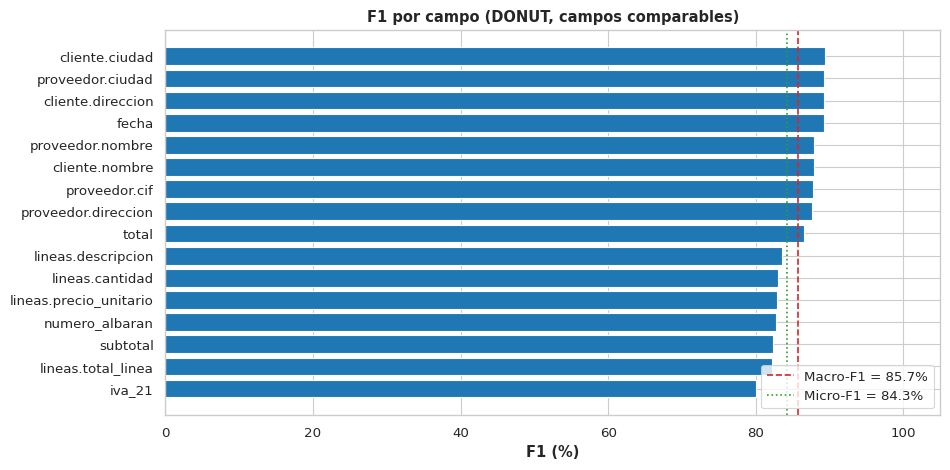

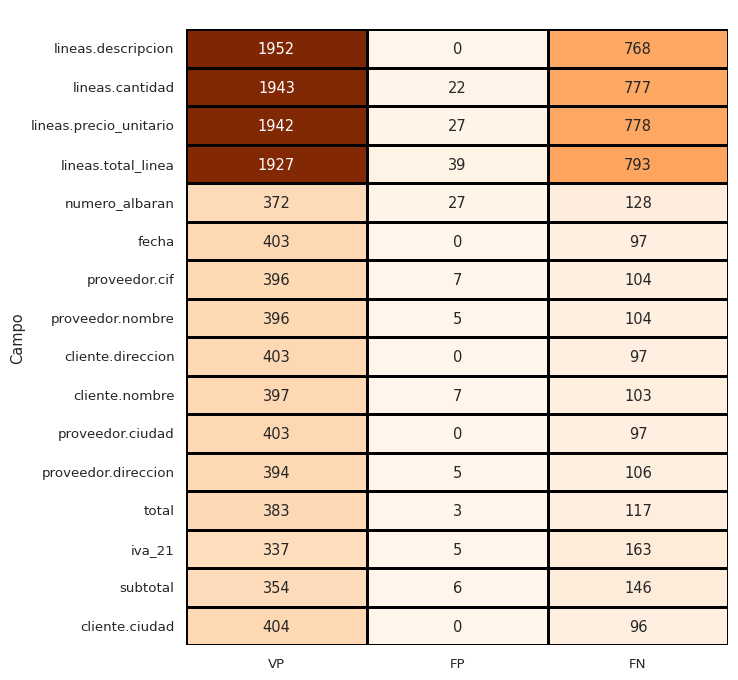

Global -> Micro-F1: 0.843 | Macro-F1: 0.857 | Weighted-F1: 0.842


,Precision,Recall,F1,CER,ANLS,Soporte
Campo,,,,,,
lineas.descripcion,100.0%,71.8%,83.6%,0.282,0.718,2720
lineas.cantidad,98.9%,71.4%,82.9%,0.285,0.714,2720
lineas.precio_unitario,98.6%,71.4%,82.8%,0.284,0.715,2720
lineas.total_linea,98.0%,70.8%,82.2%,0.287,0.713,2720
numero_albaran,93.2%,74.4%,82.8%,0.216,0.784,500
fecha,100.0%,80.6%,89.3%,0.194,0.806,500
proveedor.cif,98.3%,79.2%,87.7%,0.196,0.804,500
proveedor.nombre,98.8%,79.2%,87.9%,0.202,0.796,500
cliente.direccion,100.0%,80.6%,89.3%,0.194,0.806,500


Graficas y tabla guardadas en: /content/drive/MyDrive/STUDIES/MASTER/2Q/TFM/03__Resultados


In [ ]:
# ==============================================================================
# 05 - GRAFICAS MULTI-CAMPO (carga metrics_multifield_donut.json)
# ==============================================================================
import json, os
import pandas as pd, seaborn as sns, matplotlib.pyplot as plt
from IPython.display import display

with open(os.path.join(CONFIG["RESULTS_DIR"], "metrics_multifield_donut.json"), encoding="utf-8") as f:
    M = json.load(f)

pf = M["per_field"]
df = pd.DataFrame([
    {"Campo": k, "Precision": v["precision"], "Recall": v["recall"], "F1": v["f1"],
     "CER": v["cer"], "ANLS": v["anls"], "Soporte": v["support"]}
    for k, v in pf.items()
]).sort_values("Soporte", ascending=False).reset_index(drop=True)

sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)

# Grafica 1: F1 por campo + lineas macro/micro
orden = df.sort_values("F1", ascending=True)
plt.figure(figsize=(10, 5))
plt.barh(orden["Campo"], orden["F1"]*100, color="#1f77b4")
plt.axvline(M["resumen"]["macro_f1"]*100, color="#d62728", linestyle="--", label=f"Macro-F1 = {M['resumen']['macro_f1']*100:.1f}%")
plt.axvline(M["resumen"]["micro_f1"]*100, color="#2ca02c", linestyle=":",  label=f"Micro-F1 = {M['resumen']['micro_f1']*100:.1f}%")
plt.xlabel("F1 (%)", fontweight="bold")
plt.title("F1 por campo (DONUT, campos comparables)", fontweight="bold")
plt.xlim(0, 105); plt.legend(loc="lower right")
plt.savefig(os.path.join(CONFIG["RESULTS_DIR"], "TFM_DONUT_f1_por_campo.png"),dpi=300,bbox_inches="tight",format="png")
plt.savefig(os.path.join(CONFIG["RESULTS_DIR"], "TFM_DONUT_f1_por_campo.pdf"), dpi=300, bbox_inches="tight", format="pdf")
plt.show()

# Grafica 2: matriz TP/FP/FN por campo
mat = pd.DataFrame({"VP": [pf[k]["tp"] for k in df["Campo"]],
                    "FP": [pf[k]["fp"] for k in df["Campo"]],
                    "FN": [pf[k]["fn"] for k in df["Campo"]]}, index=df["Campo"])
plt.figure(figsize=(7, max(4, 0.5*len(mat))))
sns.heatmap(mat, annot=True, fmt="d", cmap="Oranges", cbar=False, linewidths=1, linecolor="black")
plt.title(" ", fontweight="bold")
plt.savefig(os.path.join(CONFIG["RESULTS_DIR"], "TFM_DONUT_matriz_multifield.png"),dpi=300,bbox_inches="tight",format="png")
plt.savefig(os.path.join(CONFIG["RESULTS_DIR"], "TFM_DONUT_matriz_multifield.pdf"), dpi=300, bbox_inches="tight", format="pdf")
plt.show()

# Tabla
df_fmt = df.copy()
for c in ["Precision", "Recall", "F1"]:
    df_fmt[c] = (df_fmt[c]*100).round(1).astype(str) + "%"
df_fmt["CER"] = df_fmt["CER"].round(3); df_fmt["ANLS"] = df_fmt["ANLS"].round(3)
df_fmt = df_fmt.set_index("Campo")
print("Global -> Micro-F1: %.3f | Macro-F1: %.3f | Weighted-F1: %.3f" % (
    M["resumen"]["micro_f1"], M["resumen"]["macro_f1"], M["resumen"]["weighted_f1"]))
display(df_fmt)
df_fmt.to_latex(os.path.join(CONFIG["RESULTS_DIR"], "TFM_DONUT_tabla_multifield.tex"))
print("Graficas y tabla guardadas en:", CONFIG["RESULTS_DIR"])


## 06 - Curvas de entrenamiento y convergencia

Esta celda carga el historial de entrenamiento desde el archivo `trainer_state.json` más reciente almacenado en los *checkpoints*.

- **Independiente del entrenamiento:** permite analizar los resultados sin necesidad de mantener el objeto `trainer` en memoria.
- **Cálculo automático:** los pasos por época se obtienen directamente del historial registrado.

**Nota:** Como la selección del mejor modelo se basó en la pérdida (`metric_for_best_model='loss'`) y no se definieron métricas adicionales, las gráficas muestran únicamente la evolución de la pérdida (entrenamiento y validación) y la tasa de aprendizaje.

TABLA DE CONVERGENCIA:


,Epoch,Step,Train Loss,Val Loss
0,0.2,100,3.9316,0.9032
1,0.4,200,0.3017,0.0443
2,0.6,300,0.1174,0.0193
3,0.8,400,0.0816,0.0145
4,1.0,500,0.0447,0.0081
5,1.2,600,0.0352,0.0063
6,1.4,700,0.0291,0.0059
7,1.6,800,0.0248,0.0052
8,1.8,900,0.0302,0.0054
9,2.0,1000,0.0168,0.0042


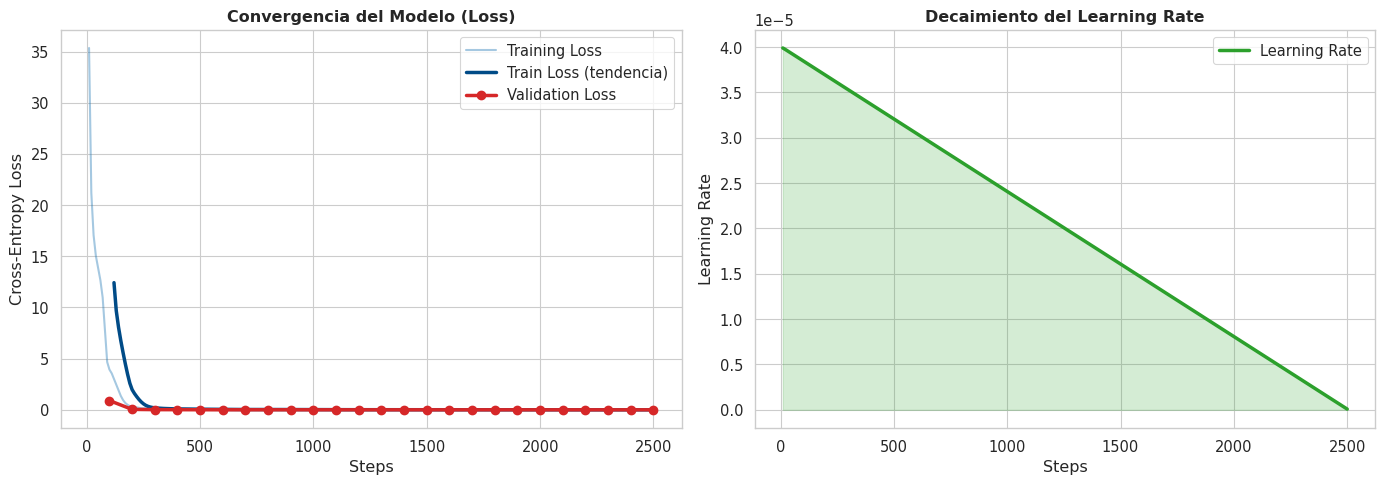

Curvas guardadas en: /content/drive/MyDrive/STUDIES/MASTER/2Q/TFM/03__Resultados/TFM_DONUT_curvas_entrenamiento.pdf | steps/epoch: 500.0


In [ ]:
# ==============================================================================
# 06 - CURVAS DE LOSS / LEARNING RATE (desde trainer_state.json)
# ==============================================================================
import json, glob, os
import pandas as pd, seaborn as sns, matplotlib.pyplot as plt
from IPython.display import display

estados = sorted(
    glob.glob(os.path.join(CONFIG["CKPT_DIR"], "checkpoint-*", "trainer_state.json")),
    key=lambda p: int(p.split("checkpoint-")[1].split(os.sep)[0]),
)
if not estados:
    raise FileNotFoundError(
        f"No hay trainer_state.json bajo {CONFIG['CKPT_DIR']}. "
        "Si solo guardaste el modelo FINAL sin checkpoints, exporta log_history al entrenar."
    )

estado = json.load(open(estados[-1], encoding="utf-8"))
log_history = estado["log_history"]

# steps/epoch DERIVADO (no hardcodeado): global_step / epoch final
steps_por_epoch = (estado["global_step"] / estado["epoch"]) if estado.get("epoch") else None

train_logs = [l for l in log_history if "loss" in l and "eval_loss" not in l]
eval_logs  = [l for l in log_history if "eval_loss" in l]

train_steps = [l["step"] for l in train_logs]
train_loss  = [l["loss"] for l in train_logs]
lr_steps    = [l["step"] for l in train_logs if "learning_rate" in l]
lrs         = [l["learning_rate"] for l in train_logs if "learning_rate" in l]
eval_steps  = [l["step"] for l in eval_logs]
eval_loss   = [l["eval_loss"] for l in eval_logs]

# Tabla de convergencia
filas = []
for el in eval_logs:
    step = el["step"]
    t_loss = next((tl["loss"] for tl in reversed(train_logs) if tl["step"] <= step), None)
    fila = {"Step": step, "Train Loss": round(t_loss, 4) if t_loss else None,
            "Val Loss": round(el["eval_loss"], 4)}
    if steps_por_epoch:
        fila = {"Epoch": round(step / steps_por_epoch, 2), **fila}
    filas.append(fila)
df_conv = pd.DataFrame(filas)
print("TABLA DE CONVERGENCIA:")
display(df_conv)
df_conv.to_csv(os.path.join(CONFIG["RESULTS_DIR"], "TFM_DONUT_tabla_resultados.csv"), index=False)
df_conv.to_latex(os.path.join(CONFIG["RESULTS_DIR"], "TFM_DONUT_tabla_resultados.tex"), index=False)

sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(train_steps, train_loss, label="Training Loss", color="#1f77b4", alpha=0.4, linewidth=1.5)
if len(train_loss) > 5:
    suave = pd.Series(train_loss).rolling(window=max(1, len(train_loss)//20)).mean()
    ax[0].plot(train_steps, suave, label="Train Loss (tendencia)", color="#004b87", linewidth=2.5)
ax[0].plot(eval_steps, eval_loss, marker="o", markersize=6, label="Validation Loss", color="#d62728", linewidth=2.5)
ax[0].set_title("Convergencia del Modelo (Loss)", fontweight="bold")
ax[0].set_xlabel("Steps"); ax[0].set_ylabel("Cross-Entropy Loss"); ax[0].legend()

ax[1].plot(lr_steps, lrs, color="#2ca02c", linewidth=2.5, label="Learning Rate")
ax[1].fill_between(lr_steps, lrs, alpha=0.2, color="#2ca02c")
ax[1].set_title("Decaimiento del Learning Rate", fontweight="bold")
ax[1].set_xlabel("Steps"); ax[1].set_ylabel("Learning Rate")
ax[1].ticklabel_format(axis="y", style="sci", scilimits=(0, 0)); ax[1].legend()

plt.tight_layout()
ruta = os.path.join(CONFIG["RESULTS_DIR"], "TFM_DONUT_curvas_entrenamiento.pdf")
plt.savefig(ruta, dpi=300, bbox_inches="tight", format="pdf")
plt.show()
print("Curvas guardadas en:", ruta, "| steps/epoch:", steps_por_epoch)


## 07 - Diagnóstico cualitativo y depuración

Esta sección reúne herramientas de inspección y análisis sobre el conjunto de prueba utilizando el modelo cargado en la sección 03.

- **07a · Inspección visual:** compara la imagen del documento con la predicción generada y el *Ground Truth*.
- **07b · Análisis de salida bruta:** muestra la secuencia de texto generada por el modelo antes de su conversión a JSON, facilitando la detección de errores de formato.
- **07c · Validación de parseo:** recorre el conjunto de prueba para identificar casos cuya salida puede convertirse correctamente a un objeto JSON estructurado.

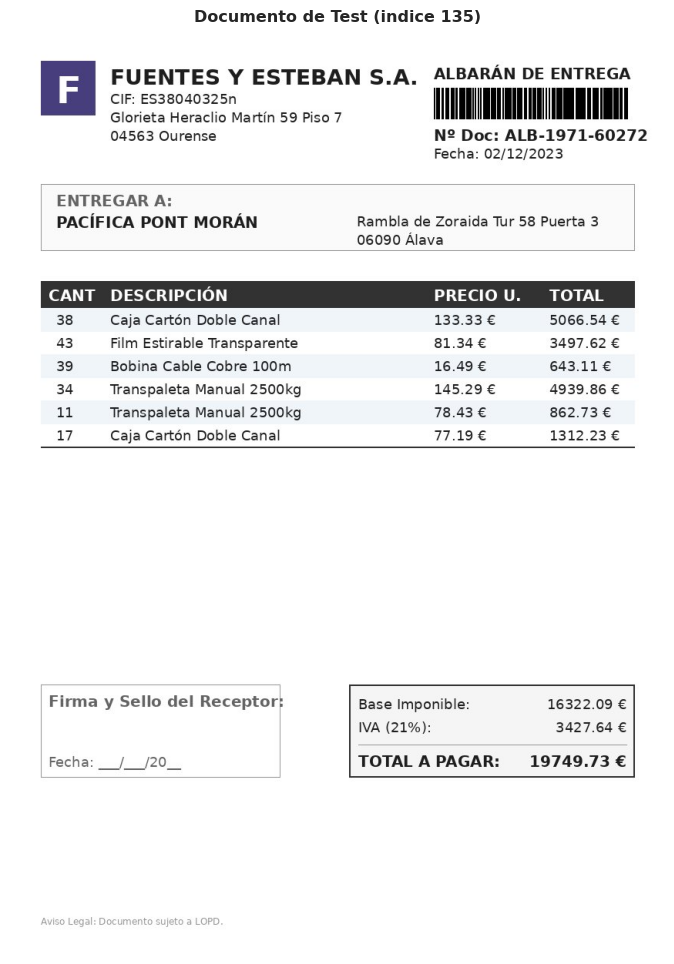

PREDICCION:
{
    "numero_albaran": "ALB-1971-60272",
    "fecha": "02/12/2023",
    "proveedor": {
        "nombre": "Fuentes y Esteban S.A.",
        "direccion": "Glorieta Heraclio Martín 59 Piso 7",
        "ciudad": "04563 Ourense",
        "cif": "ES38040325n"
    },
    "cliente": {
        "nombre": "Pacífica Pont Morán",
        "direccion": "Rambla de Zoraida Tur 58 Puerta 3",
        "ciudad": "06090 Álava"
    },
    "lineas": [
        {
            "descripcion": "Caja Cartón Doble Canal",
            "cantidad": "38",
            "precio_unitario": "133.33",
            "total_linea": "5066.54"
        },
        {
            "descripcion": "Film Estirable Transparente",
            "cantidad": "43",
            "precio_unitario": "81.34",
            "total_linea": "3497.62"
        },
        {
            "descripcion": "Bobina Cable Cobre 100m",
            "cantidad": "39",
            "precio_unitario": "16.49",
            "total_linea": "643.11"
        },
     

In [ ]:
# ==============================================================================
# 07a - DOCUMENTO ALEATORIO: imagen + prediccion vs ground truth
# ==============================================================================
import random, json, torch, matplotlib.pyplot as plt

idx = random.randint(0, len(dataset_test) - 1)
muestra = dataset_test[idx]
imagen = muestra["image"].convert("RGB")
gt = json.loads(muestra["ground_truth"])["gt_parse"]

pixel_values = processor_final(imagen, size=CONFIG["IMG_SIZE"], return_tensors="pt").pixel_values.to(device)
decoder_input_ids = processor_final.tokenizer("<s_cord-v2>", add_special_tokens=False, return_tensors="pt").input_ids.to(device)
with torch.no_grad():
    outputs = model_final.generate(
        pixel_values, decoder_input_ids=decoder_input_ids,
        max_length=model_final.decoder.config.max_position_embeddings,
        pad_token_id=processor_final.tokenizer.pad_token_id,
        eos_token_id=processor_final.tokenizer.eos_token_id,
        use_cache=True, bad_words_ids=[[processor_final.tokenizer.unk_token_id]],
        return_dict_in_generate=True,
    )
seq = processor_final.batch_decode(outputs.sequences)[0]
seq = (seq.replace(processor_final.tokenizer.eos_token, "")
          .replace(processor_final.tokenizer.pad_token, "")
          .replace("<s_cord-v2>", "", 1))
pred = processor_final.token2json(seq)

plt.figure(figsize=(10, 12)); plt.imshow(imagen); plt.axis("off")
plt.title(f"Documento de Test (indice {idx})", fontweight="bold"); plt.show()
print("PREDICCION:"); print(json.dumps(pred, indent=4, ensure_ascii=False))
print("\nGROUND TRUTH:"); print(json.dumps(gt, indent=4, ensure_ascii=False))


In [ ]:
# ==============================================================================
# 07b - AUTOPSIA RAW (cadena de tokens sin parsear) -- usa json2token de Utils
# ==============================================================================
import random, json, torch

idx = random.randint(0, len(dataset_test) - 1)
item = dataset_test[idx]
imagen = item["image"].convert("RGB")
gt = json.loads(item["ground_truth"])["gt_parse"]
gt_limpio = processor_final.token2json(json2token(gt))

pixel_values = processor_final(imagen, size=CONFIG["IMG_SIZE"], return_tensors="pt").pixel_values.to(device)
decoder_input_ids = processor_final.tokenizer("<s_cord-v2>", add_special_tokens=False, return_tensors="pt").input_ids.to(device)
with torch.no_grad():
    outputs = model_final.generate(
        pixel_values, decoder_input_ids=decoder_input_ids,
        max_length=model_final.decoder.config.max_position_embeddings,
        pad_token_id=processor_final.tokenizer.pad_token_id,
        eos_token_id=processor_final.tokenizer.eos_token_id,
        use_cache=True, bad_words_ids=[[processor_final.tokenizer.unk_token_id]],
        return_dict_in_generate=True,
    )
seq = processor_final.batch_decode(outputs.sequences)[0]
pred = (seq.replace(processor_final.tokenizer.eos_token, "")
           .replace(processor_final.tokenizer.pad_token, "")
           .replace("<s_cord-v2>", "", 1))
print(f"DOCUMENTO {idx}\n\nGROUND TRUTH:\n{gt_limpio}\n\n{'-'*80}\n\nPREDICCION RAW:\n{pred}")


DOCUMENTO 78

GROUND TRUTH:
{'tipo_documento': 'ALBARÁN DE ENTREGA', 'numero_albaran': 'ALB-2012-31540', 'fecha': '04/09/2023', 'proveedor': {'nombre': 'Despacho Globales S.Coop.', 'direccion': 'Calle Blas Estévez 89', 'ciudad': '04244 Zamora', 'cif': 'ESB97453961'}, 'cliente': {'nombre': 'Asdrubal Hoyos Roldán', 'direccion': 'Calle Aníbal Vilalta 3 Puerta 9', 'ciudad': '44214 Cádiz'}, 'lineas': [{'descripcion': 'Transpaleta Manual 2500kg', 'cantidad': '28', 'precio_unitario': '140.32', 'total_linea': '3928.96'}, {'descripcion': 'Caja Cartón Doble Canal', 'cantidad': '29', 'precio_unitario': '58.35', 'total_linea': '1692.15'}, {'descripcion': 'Bidón Aceite Motor 50L', 'cantidad': '50', 'precio_unitario': '17.34', 'total_linea': '867.0'}, {'descripcion': 'Kit Herramientas Básicas', 'cantidad': '46', 'precio_unitario': '112.77', 'total_linea': '5187.42'}, {'descripcion': 'Caja Cartón Doble Canal', 'cantidad': '6', 'precio_unitario': '21.25', 'total_linea': '127.5'}, {'descripcion': 'Bidó

In [ ]:
# ==============================================================================
# 07c - PRIMERA PREDICCION PARSEABLE A JSON (diagnostico de formato)
# ==============================================================================
import json, torch

for i in range(len(dataset_test)):
    item = dataset_test[i]
    imagen = item["image"].convert("RGB")
    gt = json.loads(item["ground_truth"])["gt_parse"]

    pixel_values = processor_final(imagen, size=CONFIG["IMG_SIZE"], return_tensors="pt").pixel_values.to(device)
    decoder_input_ids = processor_final.tokenizer("<s_cord-v2>", add_special_tokens=False, return_tensors="pt").input_ids.to(device)
    with torch.no_grad():
        outputs = model_final.generate(
            pixel_values, decoder_input_ids=decoder_input_ids,
            max_length=model_final.decoder.config.max_position_embeddings,
            pad_token_id=processor_final.tokenizer.pad_token_id,
            eos_token_id=processor_final.tokenizer.eos_token_id,
            use_cache=True, bad_words_ids=[[processor_final.tokenizer.unk_token_id]],
            return_dict_in_generate=True,
        )
    seq = processor_final.batch_decode(outputs.sequences)[0]
    pred = (seq.replace(processor_final.tokenizer.eos_token, "")
               .replace(processor_final.tokenizer.pad_token, "")
               .replace("<s_cord-v2>", "", 1))
    try:
        pj = processor_final.token2json(pred)
        if isinstance(pj, dict) and len(pj.keys()) > 2:
            print(f"DOCUMENTO {i} -> JSON VALIDO\n" + "="*80)
            print("GROUND TRUTH:\n", json.dumps(gt, indent=4, ensure_ascii=False))
            print("-"*80)
            print("PREDICHO:\n", json.dumps(pj, indent=4, ensure_ascii=False))
            break
    except Exception:
        continue


DOCUMENTO 0 -> JSON VALIDO
GROUND TRUTH:
 {
    "tipo_documento": "ALBARÁN DE ENTREGA",
    "numero_albaran": "ALB-2007-33152",
    "fecha": "26/08/2020",
    "proveedor": {
        "nombre": "Restauración CN S.L.",
        "direccion": "Cañada Flavio Hidalgo 98",
        "ciudad": "10461 Baleares",
        "cif": "ES23343012a"
    },
    "cliente": {
        "nombre": "Calisto Iñiguez Múñiz",
        "direccion": "Pasaje Amparo Espejo 359",
        "ciudad": "04448 Guadalajara"
    },
    "lineas": [
        {
            "descripcion": "Palet Europeo 1200x800",
            "cantidad": 40,
            "precio_unitario": 56.46,
            "total_linea": 2258.4
        },
        {
            "descripcion": "Bobina Cable Cobre 100m",
            "cantidad": 33,
            "precio_unitario": 19.51,
            "total_linea": 643.83
        },
        {
            "descripcion": "Film Estirable Transparente",
            "cantidad": 24,
            "precio_unitario": 52.47,
          

## 08 - Análisis de robustez

Esta sección evalúa el comportamiento del modelo sobre conjuntos de prueba con distintos niveles de degradación, simulando condiciones adversas del entorno real.

- **08a - Carga de datos:** recupera los datos de evaluación almacenados en disco y los carga automáticamente en memoria.
- **08b - Evaluación de robustez:** mide el impacto de la degradación sobre las métricas de extracción (F1, CER y ANLS), la validez de los resultados generados y el tiempo de inferencia.

Los resultados se almacenan en el archivo `robustez_multifield_donut.json` para su posterior análisis.

In [ ]:
# ==============================================================================
# 08a - CARGA DE LOS 4 NIVELES DE RUIDO DESDE DRIVE
# ==============================================================================
import os, shutil
from datasets import load_dataset

if not os.path.exists(CONFIG["ROBUSTEZ_ZIP"]):
    raise FileNotFoundError(f"No existe el ZIP de robustez: {CONFIG['ROBUSTEZ_ZIP']}")
if os.path.exists(CONFIG["LOCAL_ROBUSTEZ"]):
    shutil.rmtree(CONFIG["LOCAL_ROBUSTEZ"])
shutil.unpack_archive(CONFIG["ROBUSTEZ_ZIP"], CONFIG["LOCAL_ROBUSTEZ"], 'zip')
print("Robustez extraida.")

datasets_robustez = {}
for ruido in [0, 1, 2, 3]:
    carpeta = os.path.join(CONFIG["LOCAL_ROBUSTEZ"], f"Ruido_{ruido}")
    # Robusto: carga el DatasetDict y toma el primer split exista 'train' o 'test'.
    ds_dict = load_dataset("imagefolder", data_dir=carpeta)
    ds = ds_dict[list(ds_dict.keys())[0]]
    datasets_robustez[f"ruido_{ruido}"] = ds
    print(f"  Ruido {ruido}: {len(ds)} documentos.")
print("Variable 'datasets_robustez' lista.")


Robustez extraida.


Resolving data files:   0%|          | 0/500 [00:00<?, ?it/s]

Generating test split: 0 examples [00:00, ? examples/s]

  Ruido 0: 500 documentos.


Resolving data files:   0%|          | 0/500 [00:00<?, ?it/s]

...

Generating test split: 0 examples [00:00, ? examples/s]

  Ruido 2: 500 documentos.


Resolving data files:   0%|          | 0/500 [00:00<?, ?it/s]

Generating test split: 0 examples [00:00, ? examples/s]

  Ruido 3: 500 documentos.
Variable 'datasets_robustez' lista.


In [ ]:
# ==============================================================================
# 08b - ROBUSTEZ MULTI-CAMPO (0-3) -> robustez_multifield_donut.json
# ==============================================================================
import json, time, os
from tqdm.auto import tqdm

model_final.eval()
robustez = []

for ruido in [0, 1, 2, 3]:
    ds = datasets_robustez[f"ruido_{ruido}"]
    n = len(ds)
    acc = nuevo_acc(); errores_json = 0; t0 = time.time()
    with medir_recursos('eval_robustez', n_items=len(ds), extra={'modelo': 'DONUT', 'ruido': ruido}):
     for item in tqdm(ds, desc=f"Ruido {ruido}"):
          pred, _, ok = run_inference(item, processor_final, model_final, device, CONFIG["IMG_SIZE"])
          if not ok:
              errores_json += 1
          gt = json.loads(item["ground_truth"])["gt_parse"]
          eval_document(gt, pred, acc)
    dt = time.time() - t0
    per_field, resumen = agregar_metricas(acc)
    robustez.append({
        "ruido": ruido,
        "json_invalidos_pct": (errores_json/n*100) if n else 0.0,
        "latencia_s": round(dt/n, 2) if n else 0.0,
        "resumen": resumen,
        "per_field": per_field,
    })

ruta = os.path.join(CONFIG["RESULTS_DIR"], "robustez_multifield_donut.json")
with open(ruta, "w", encoding="utf-8") as f:
    json.dump(robustez, f, ensure_ascii=False, indent=2)
print("Robustez multi-campo guardada en:", ruta)
for r in robustez:
    print(f"  Ruido {r['ruido']}: Macro-F1 {r['resumen']['macro_f1']:.3f} | "
          f"Micro-F1 {r['resumen']['micro_f1']:.3f} | JSON roto {r['json_invalidos_pct']:.1f}%")


Ruido 0:   0%|          | 0/500 [00:00<?, ?it/s]

[BENCH] eval_robustez: 897.58s (1.7952s/item) | CPU~96.8% | RAM 1868.4MB | VRAM 1521.9MB | disco R/W 0.0/0.0MB


Ruido 1:   0%|          | 0/500 [00:00<?, ?it/s]

[BENCH] eval_robustez: 892.50s (1.785s/item) | CPU~99.1% | RAM 1854.8MB | VRAM 1521.4MB | disco R/W 0.0/0.0MB


Ruido 2:   0%|          | 0/500 [00:00<?, ?it/s]

[BENCH] eval_robustez: 940.34s (1.8807s/item) | CPU~99.7% | RAM 1827.3MB | VRAM 1521.4MB | disco R/W 0.0/0.0MB


Ruido 3:   0%|          | 0/500 [00:00<?, ?it/s]

[BENCH] eval_robustez: 1050.47s (2.1009s/item) | CPU~99.1% | RAM 1856.0MB | VRAM 1521.4MB | disco R/W 0.0/0.0MB
Robustez multi-campo guardada en: /content/drive/MyDrive/STUDIES/MASTER/2Q/TFM/03__Resultados/robustez_multifield_donut.json
  Ruido 0: Macro-F1 0.815 | Micro-F1 0.793 | JSON roto 0.0%
  Ruido 1: Macro-F1 0.736 | Micro-F1 0.724 | JSON roto 0.0%
  Ruido 2: Macro-F1 0.645 | Micro-F1 0.635 | JSON roto 0.0%
  Ruido 3: Macro-F1 0.560 | Micro-F1 0.553 | JSON roto 0.0%


## 09 - Análisis de robustez y degradación

Esta sección procesa el archivo `robustez_multifield_donut.json` para generar el panel de resultados de robustez.

- **Curvas de degradación:** muestran la evolución del rendimiento global (Macro-F1 y Micro-F1) y de campos clave como `total` y `numero_albaran` a medida que aumenta el nivel de ruido.
- **Resumen de métricas:** consolida F1-Score, CER, ANLS, tasa de errores de formato JSON y latencia para cada nivel de degradación.

Los resultados se exportan automáticamente en formato LaTeX para su inclusión en la memoria.

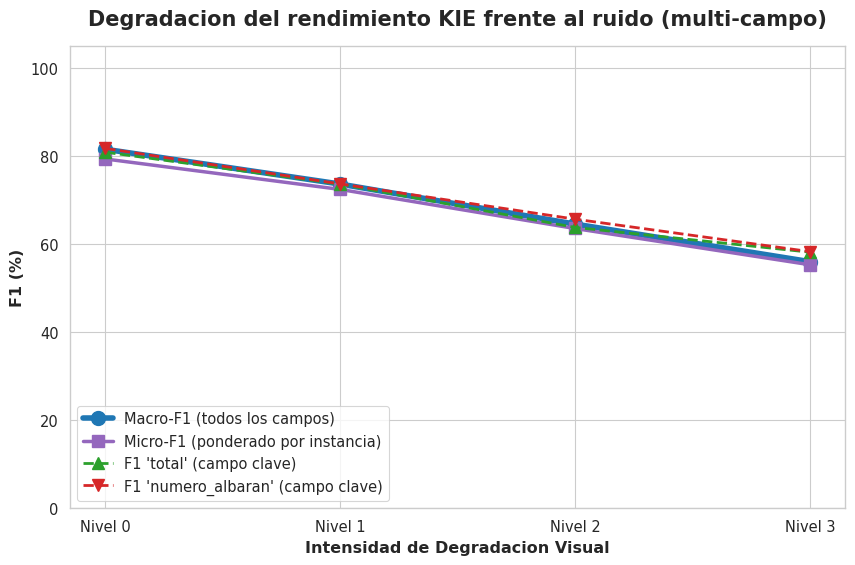

TABLA DE ROBUSTEZ MULTI-CAMPO:


,Macro-F1,Micro-F1,Weighted-F1,Macro-CER,Macro-ANLS,JSON roto,Latencia (s)
Ruido,,,,,,,
Nivel 0,81.5%,79.3%,79.2%,0.300,0.700,0.0%,1.80
Nivel 1,73.6%,72.4%,72.3%,0.391,0.609,0.0%,1.79
Nivel 2,64.5%,63.5%,63.5%,0.482,0.516,0.0%,1.88
Nivel 3,56.0%,55.3%,55.2%,0.568,0.430,0.0%,2.10


Panel y tabla guardados en: /content/drive/MyDrive/STUDIES/MASTER/2Q/TFM/03__Resultados


In [ ]:
# ==============================================================================
# 09 - PANEL DE ROBUSTEZ MULTI-CAMPO (carga robustez_multifield_donut.json)
# ==============================================================================
import json, os
import pandas as pd, seaborn as sns, matplotlib.pyplot as plt
from IPython.display import display

with open(os.path.join(CONFIG["RESULTS_DIR"], "robustez_multifield_donut.json"), encoding="utf-8") as f:
    RB = json.load(f)

x = [f"Nivel {r['ruido']}" for r in RB]
macro = [r["resumen"]["macro_f1"]*100 for r in RB]
micro = [r["resumen"]["micro_f1"]*100 for r in RB]
def f1_de(r, campo): return r["per_field"].get(campo, {}).get("f1", float("nan"))*100
total_f1 = [f1_de(r, "total") for r in RB]
num_f1   = [f1_de(r, "numero_albaran") for r in RB]

sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.figure(figsize=(10, 6))
plt.plot(x, macro,    marker="o", markersize=10, linewidth=4,   color="#1f77b4", label="Macro-F1 (todos los campos)")
plt.plot(x, micro,    marker="s", markersize=8,  linewidth=2.5, color="#9467bd", label="Micro-F1 (ponderado por instancia)")
plt.plot(x, total_f1, marker="^", markersize=8,  linewidth=2, linestyle="--", color="#2ca02c", label="F1 'total' (campo clave)")
plt.plot(x, num_f1,   marker="v", markersize=8,  linewidth=2, linestyle="--", color="#d62728", label="F1 'numero_albaran' (campo clave)")
plt.title("Degradacion del rendimiento KIE frente al ruido (multi-campo)", fontweight="bold", fontsize=15, pad=15)
plt.xlabel("Intensidad de Degradacion Visual", fontweight="bold"); plt.ylabel("F1 (%)", fontweight="bold")
plt.ylim(0, 105); plt.legend(loc="lower left")
plt.savefig(os.path.join(CONFIG["RESULTS_DIR"], "TFM_DONUT_robustez_multifield.pdf"), dpi=300, bbox_inches="tight", format="pdf")
plt.show()

filas = [{"Ruido": f"Nivel {r['ruido']}",
          "Macro-F1": f"{r['resumen']['macro_f1']*100:.1f}%",
          "Micro-F1": f"{r['resumen']['micro_f1']*100:.1f}%",
          "Weighted-F1": f"{r['resumen']['weighted_f1']*100:.1f}%",
          "Macro-CER": round(r['resumen']['macro_cer'], 3),
          "Macro-ANLS": round(r['resumen']['macro_anls'], 3),
          "JSON roto": f"{r['json_invalidos_pct']:.1f}%",
          "Latencia (s)": r["latencia_s"]} for r in RB]
df_rb = pd.DataFrame(filas).set_index("Ruido")
print("TABLA DE ROBUSTEZ MULTI-CAMPO:")
display(df_rb)
df_rb.to_latex(os.path.join(CONFIG["RESULTS_DIR"], "TFM_DONUT_tabla_robustez_multifield.tex"))
print("Panel y tabla guardados en:", CONFIG["RESULTS_DIR"])


## 10 - Comparativa de eficiencia y rendimiento

Esta sección analiza las métricas de consumo de recursos y latencia de DONUT, relacionándolas con su rendimiento de extracción (Macro-F1) a partir de los datos almacenados en `benchmark_costes.json`.

El objetivo es cuantificar el equilibrio entre precisión y coste computacional, destacando la ventaja de DONUT al no requerir una etapa previa de OCR. Al tratarse de una arquitectura *OCR-free*, el procesamiento se realiza de extremo a extremo, reduciendo el tiempo total por documento y eliminando la dependencia de motores externos de reconocimiento de texto.

Los resultados se integran en la comparativa final del estudio y se exportan en formatos CSV y LaTeX.

In [ ]:
# ==============================================================================
# 10 - TABLA COMPARATIVA: EFICIENCIA + RENDIMIENTO (ambos modelos)
# ==============================================================================
import json, os
import pandas as pd
from IPython.display import display

costes = []
if os.path.exists(CONFIG['BENCH_PATH']):
    with open(CONFIG['BENCH_PATH']) as f: costes = json.load(f)
if not costes:
    print('Aun no hay registros en', CONFIG['BENCH_PATH'])
else:
    df_cost = pd.DataFrame(costes)
    if 'dataset' in df_cost.columns:
        df_cost = df_cost[df_cost['dataset'] != 'CORD']  # excluye baseline CORD
    claves = [k for k in ['modelo','fase','ruido'] if k in df_cost.columns]
    df_cost = df_cost.drop_duplicates(subset=claves, keep='last')
    cols = ['modelo','fase'] + [c for c in ['ruido','ocr_cache'] if c in df_cost.columns] + \
           [c for c in ['tiempo_s','s_por_item','cpu_pct_medio','vram_pico_mb',
                        'ram_proc_mb_fin','disk_read_mb','disk_write_mb','n_items'] if c in df_cost.columns]
    df_cost = df_cost[cols].sort_values(['modelo','fase']).reset_index(drop=True)
    print('COSTES POR FASE (eficiencia):'); display(df_cost)
    df_cost.to_csv(os.path.join(CONFIG['RESULTS_DIR'],'TFM_DONUT_benchmark_costes_tabla.csv'), index=False)

def cargar_metricas(ruta, modelo):
    if not os.path.exists(ruta): return None
    with open(ruta, encoding='utf-8') as f: M = json.load(f)
    r = M['resumen']
    return {'modelo': modelo, 'Macro-F1': r['macro_f1'], 'Micro-F1': r['micro_f1'],
            'Weighted-F1': r.get('weighted_f1'), 'Macro-CER': r['macro_cer'], 'Macro-ANLS': r['macro_anls']}

filas_q = []
for ruta, m in [('metrics_multifield_donut.json','DONUT'), ('metrics_layoutlmv3.json','LayoutLMv3'), ('metrics_paddleocr.json','PaddleOCR')]:
    f = cargar_metricas(os.path.join(CONFIG['RESULTS_DIR'], ruta), m)
    if f: filas_q.append(f)

if filas_q:
    df_q = pd.DataFrame(filas_q).set_index('modelo')
    print('\nRENDIMIENTO (calidad):'); display(df_q.round(3))
    df_q.to_csv(os.path.join(CONFIG['RESULTS_DIR'],'TFM_DONUT_benchmark_calidad_tabla.csv'))
else:
    print('\nAun no hay JSON de metricas (ejecuta seccion 04 en ambos notebooks).')

if costes and filas_q:
    dfc = pd.DataFrame(costes)
    if 'dataset' in dfc.columns:
        dfc = dfc[dfc['dataset'] != 'CORD']
    dfc = dfc.drop_duplicates(subset=[k for k in ['modelo','fase','ruido'] if k in dfc.columns], keep='last')
    def s_por_doc(modelo, fase):
        sub = dfc[(dfc['modelo']==modelo) & (dfc['fase']==fase)]
        return float(sub['s_por_item'].iloc[-1]) if len(sub) and sub['s_por_item'].notna().any() else 0.0
    res=[]
    for fila in filas_q:
        m=fila['modelo']; ocr=s_por_doc(m,'preprocess_ocr'); inf=s_por_doc(m,'inference_test')
        res.append({'modelo':m,'Macro-F1':round(fila['Macro-F1'],3),'OCR s/doc':round(ocr,3),
                    'Inferencia s/doc':round(inf,3),'Coste total s/doc':round(ocr+inf,3)})
    df_res=pd.DataFrame(res).set_index('modelo')
    print('\nEFICIENCIA vs CALIDAD (por documento):'); display(df_res)
    df_res.to_latex(os.path.join(CONFIG['RESULTS_DIR'],'TFM_DONUT_benchmark_resumen.tex'))
    print('Tablas guardadas en:', CONFIG['RESULTS_DIR'])


COSTES POR FASE (eficiencia):


,modelo,fase,ruido,ocr_cache,tiempo_s,s_por_item,cpu_pct_medio,vram_pico_mb,ram_proc_mb_fin,disk_read_mb,disk_write_mb,n_items
0,DONUT,eval_robustez,0.0,NaN,897.578,1.7952,96.8,1521.9,1868.4,0.00,0.00,500
1,DONUT,eval_robustez,1.0,NaN,892.503,1.7850,99.1,1521.4,1854.8,0.00,0.00,500
2,DONUT,eval_robustez,2.0,NaN,940.343,1.8807,99.7,1521.4,1827.3,0.00,0.00,500
3,DONUT,eval_robustez,3.0,NaN,1050.472,2.1009,99.1,1521.4,1856.0,0.00,0.00,500
4,DONUT,inference_test,NaN,NaN,861.733,1.7235,98.1,1465.2,1718.1,100.77,0.14,500
5,LayoutLMv3,preprocess_ocr,NaN,cold,3799.151,1.4484,11.1,0.0,1980.8,0.13,1389.83,2623



RENDIMIENTO (calidad):


,Macro-F1,Micro-F1,Weighted-F1,Macro-CER,Macro-ANLS
modelo,,,,,
DONUT,0.857,0.843,0.842,0.235,0.765



EFICIENCIA vs CALIDAD (por documento):


,Macro-F1,OCR s/doc,Inferencia s/doc,Coste total s/doc
modelo,,,,
DONUT,0.857,0.0,1.724,1.724


Tablas guardadas en: /content/drive/MyDrive/STUDIES/MASTER/2Q/TFM/03__Resultados


---

# 99 - GENERACION DE DATOS Y ENTRENAMIENTO

> ## NO EJECUTAR en uso normal
>
> Estas celdas **(a)** regeneran los datasets sinteticos y **(b)** reentrenan el modelo. El modelo final ya esta guardado en Drive; las secciones 00-10 lo evaluan sin tocar nada de aqui.
>
> Ejecuta esta seccion **solo** si necesitas regenerar el dataset o reentrenar desde cero. En ese caso, el orden es: 00 -> 01 -> 99 (generacion) -> 99 (entrenamiento) y luego vuelve a 02-10 para evaluar.

`json2token` ya no se define aqui (vive en la seccion 01).

### 99.1 - Generación del conjunto de datos sintético

Esta subsección genera el corpus documental utilizado para el entrenamiento y la evaluación del modelo, garantizando la reproducibilidad mediante una semilla fija (`seed=42`).

El proceso se divide en tres etapas:

1. **Generación y renderizado:** creación de albaranes sintéticos mediante `Faker` y su representación visual con `Pillow`, reproduciendo un formato similar al de documentos logísticos reales.
2. **Validación visual:** generación de ejemplos de muestra para verificar la correcta distribución de los elementos y la calidad de las imágenes producidas.
3. **Generación masiva y almacenamiento:** creación de 5.000 documentos, construcción del archivo `metadata.jsonl` compatible con Hugging Face y empaquetado automático del conjunto de datos en Google Drive.

**Nota:** El conjunto se genera sin degradaciones visuales (`nivel de ruido = 0`), constituyendo la versión de referencia utilizada en las fases posteriores del estudio.

In [ ]:
# ==============================================================================
# CELDA 6 - MOTOR DE RENDERIZADO "CORPORATE" (acentos + wrapping + layout que fluye)
# ==============================================================================
# v6.1: DejaVuSans (acentos garantizados; antes caia a load_default sin tildes).
#       Campos de texto largos ya NO se truncan: se envuelven y el layout se recoloca.
#       generar_datos_json() se conserva intacto (bug de v6 corregido).
import os
import random
from PIL import Image, ImageDraw, ImageFont
from matplotlib import font_manager
from faker import Faker

fake = Faker('es_ES')

ARTICULOS_LOGISTICOS = [
    "Palet Europeo 1200x800", "Caja Tornillos Hexagonales M8",
    "Bobina Cable Cobre 100m", "Bidón Aceite Motor 50L",
    "Film Estirable Transparente", "Cinta Adhesiva Embalaje",
    "Estantería Metálica Carga", "Transpaleta Manual 2500kg",
    "Caja Cartón Doble Canal", "Kit Herramientas Básicas"
]

def _find_font(bold=False):
    # Roboto si existe (entorno original); si no, DejaVuSans (acentos garantizados en Colab)
    # v6.1 utilizaremos siempre DejaVuSans
    rel = "Roboto-Bold.ttf" if bold else "Roboto-Regular.ttf"
    if os.path.exists(rel):
        return rel
    fp = font_manager.FontProperties(family='DejaVu Sans', weight=('bold' if bold else 'normal'))
    return font_manager.findfont(fp)

class GeneradorAlbaranesPro:
    def __init__(self):
        reg, bld = _find_font(False), _find_font(True)
        self.f_tiny   = ImageFont.truetype(reg, 12)
        self.f_normal = ImageFont.truetype(reg, 18)
        self.f_bold   = ImageFont.truetype(bld, 20)
        self.f_title  = ImageFont.truetype(bld, 28)   # 32 -> 28 para dar aire al wrapping
        self.f_logo   = ImageFont.truetype(bld, 48)

    def generar_datos_json(self):
        num_lineas = random.randint(3, 8)
        lineas = []
        subtotal = 0.0
        for _ in range(num_lineas):
            cant = random.randint(1, 50)
            precio_uni = round(random.uniform(5.0, 150.0), 2)
            total_linea = round(cant * precio_uni, 2)
            subtotal += total_linea
            lineas.append({"descripcion": random.choice(ARTICULOS_LOGISTICOS),
                           "cantidad": cant, "precio_unitario": precio_uni, "total_linea": total_linea})
        subtotal = round(subtotal, 2)
        iva = round(subtotal * 0.21, 2)
        total_pagar = round(subtotal + iva, 2)
        return {
            "tipo_documento": "ALBARÁN DE ENTREGA",
            "numero_albaran": f"ALB-{fake.year()}-{random.randint(10000, 99999)}",
            "fecha": fake.date_this_decade().strftime("%d/%m/%Y"),
            "proveedor": {"nombre": fake.company(), "direccion": fake.street_address(),
                          "ciudad": f"{fake.postcode()} {fake.city()}", "cif": fake.vat_id()},
            "cliente": {"nombre": fake.name(), "direccion": fake.street_address(),
                        "ciudad": f"{fake.postcode()} {fake.city()}"},
            "lineas": lineas, "subtotal": subtotal, "iva_21": iva, "total": total_pagar
        }

    @staticmethod
    def _wrap(draw, text, font, max_w):
        words = str(text).split()
        lines, cur = [], ""
        for w in words:
            test = (cur + " " + w).strip()
            if not cur or draw.textlength(test, font=font) <= max_w:
                cur = test
            else:
                lines.append(cur); cur = w
        if cur: lines.append(cur)
        return lines or [""]

    def _draw_wrapped(self, draw, xy, text, font, max_w, fill, lh=None):
        x, y = xy
        lh = lh or (font.size + 6)
        for ln in self._wrap(draw, text, font, max_w):
            draw.text((x, y), ln, font=font, fill=fill); y += lh
        return y

    def _dibujar_codigo_barras(self, draw, x_start, y_start, width, height):
        x = x_start
        while x < x_start + width:
            w = random.randint(1, 4)
            draw.rectangle([x, y_start, x+w, y_start+height], fill=(0,0,0)); x += w + random.randint(1, 3)

    def dibujar_albaran(self, datos):
        img = Image.new('RGB', (850, 1200), color=(255, 255, 255))
        draw = ImageDraw.Draw(img); tc = (30, 30, 30)

        cl = (random.randint(50,200), random.randint(50,200), random.randint(50,200))
        draw.rectangle([40, 40, 110, 110], fill=cl)
        draw.text((60, 50), datos['proveedor']['nombre'][0], font=self.f_logo, fill=(255,255,255))

        PROV_W = 400
        y = 45
        y = self._draw_wrapped(draw, (130, y), datos['proveedor']['nombre'].upper(), self.f_title, PROV_W, tc, lh=32)
        y += 2
        y = self._draw_wrapped(draw, (130, y), f"CIF: {datos['proveedor']['cif']}", self.f_normal, PROV_W, tc)
        y = self._draw_wrapped(draw, (130, y), datos['proveedor']['direccion'], self.f_normal, PROV_W, tc)
        y = self._draw_wrapped(draw, (130, y), datos['proveedor']['ciudad'], self.f_normal, PROV_W, tc)
        prov_bottom = y

        draw.text((550, 45), datos['tipo_documento'], font=self.f_bold, fill=tc)
        self._dibujar_codigo_barras(draw, 550, 75, 250, 40)
        draw.text((550, 125), f"Nº Doc: {datos['numero_albaran']}", font=self.f_bold, fill=tc)
        draw.text((550, 150), f"Fecha: {datos['fecha']}", font=self.f_normal, fill=tc)
        meta_bottom = 180

        cli_top = max(prov_bottom, meta_bottom) + 20
        nom_lines = self._wrap(draw, datos['cliente']['nombre'].upper(), self.f_bold, 360)
        dir_lines = self._wrap(draw, datos['cliente']['direccion'], self.f_normal, 330)
        cli_lines = self._wrap(draw, datos['cliente']['ciudad'], self.f_normal, 330)
        alto_izq = 30 + len(nom_lines)*26
        alto_der = len(dir_lines)*24 + len(cli_lines)*24
        cli_h = max(alto_izq, alto_der) + 30
        draw.rectangle([40, cli_top, 810, cli_top+cli_h], outline=(150,150,150), width=1, fill=(250,250,250))
        draw.text((60, cli_top+10), "ENTREGAR A:", font=self.f_bold, fill=(100,100,100))
        self._draw_wrapped(draw, (60, cli_top+38), datos['cliente']['nombre'].upper(), self.f_bold, 360, tc, lh=26)
        yd = self._draw_wrapped(draw, (450, cli_top+38), datos['cliente']['direccion'], self.f_normal, 330, tc)
        self._draw_wrapped(draw, (450, yd), datos['cliente']['ciudad'], self.f_normal, 330, tc)

        y_actual = cli_top + cli_h + 40
        draw.rectangle([40, y_actual, 810, y_actual+35], fill=(50,50,50))
        draw.text((50, y_actual+7), "CANT", font=self.f_bold, fill=(255,255,255))
        draw.text((130, y_actual+7), "DESCRIPCIÓN", font=self.f_bold, fill=(255,255,255))
        draw.text((550, y_actual+7), "PRECIO U.", font=self.f_bold, fill=(255,255,255))
        draw.text((700, y_actual+7), "TOTAL", font=self.f_bold, fill=(255,255,255))
        y_actual += 35
        for idx, ln in enumerate(datos['lineas']):
            if idx % 2 == 0: draw.rectangle([40, y_actual, 810, y_actual+30], fill=(240,245,250))
            draw.text((60, y_actual+5), str(ln['cantidad']), font=self.f_normal, fill=tc)
            draw.text((130, y_actual+5), ln['descripcion'][:30], font=self.f_normal, fill=tc)
            draw.text((550, y_actual+5), f"{ln['precio_unitario']:.2f} €", font=self.f_normal, fill=tc)
            draw.text((700, y_actual+5), f"{ln['total_linea']:.2f} €", font=self.f_normal, fill=tc)
            y_actual += 30
        draw.line([(40,y_actual),(810,y_actual)], fill=(50,50,50), width=2)

        y_tot = max(y_actual+40, 850)
        draw.rectangle([40, y_tot, 350, y_tot+120], outline=(150,150,150), width=1)
        draw.text((50, y_tot+10), "Firma y Sello del Receptor:", font=self.f_bold, fill=(100,100,100))
        draw.text((50, y_tot+90), "Fecha: ___/___/20__", font=self.f_normal, fill=(100,100,100))
        draw.rectangle([440, y_tot, 810, y_tot+120], fill=(245,245,245), outline=(50,50,50), width=2)
        def _rt(txt, yy, font):
            w = draw.textlength(txt, font=font)
            draw.text((800 - w, yy), txt, font=font, fill=tc)
        draw.text((452, y_tot+15), "Base Imponible:", font=self.f_normal, fill=tc)
        _rt(f"{datos['subtotal']:.2f} €", y_tot+15, self.f_normal)
        draw.text((452, y_tot+45), "IVA (21%):", font=self.f_normal, fill=tc)
        _rt(f"{datos['iva_21']:.2f} €", y_tot+45, self.f_normal)
        draw.line([(452,y_tot+78),(800,y_tot+78)], fill=(150,150,150), width=1)
        draw.text((452, y_tot+88), "TOTAL A PAGAR:", font=self.f_bold, fill=tc)
        _rt(f"{datos['total']:.2f} €", y_tot+88, self.f_bold)
        draw.text((40, 1150), "Aviso Legal: Documento sujeto a LOPD.", font=self.f_tiny, fill=(150,150,150))
        return img


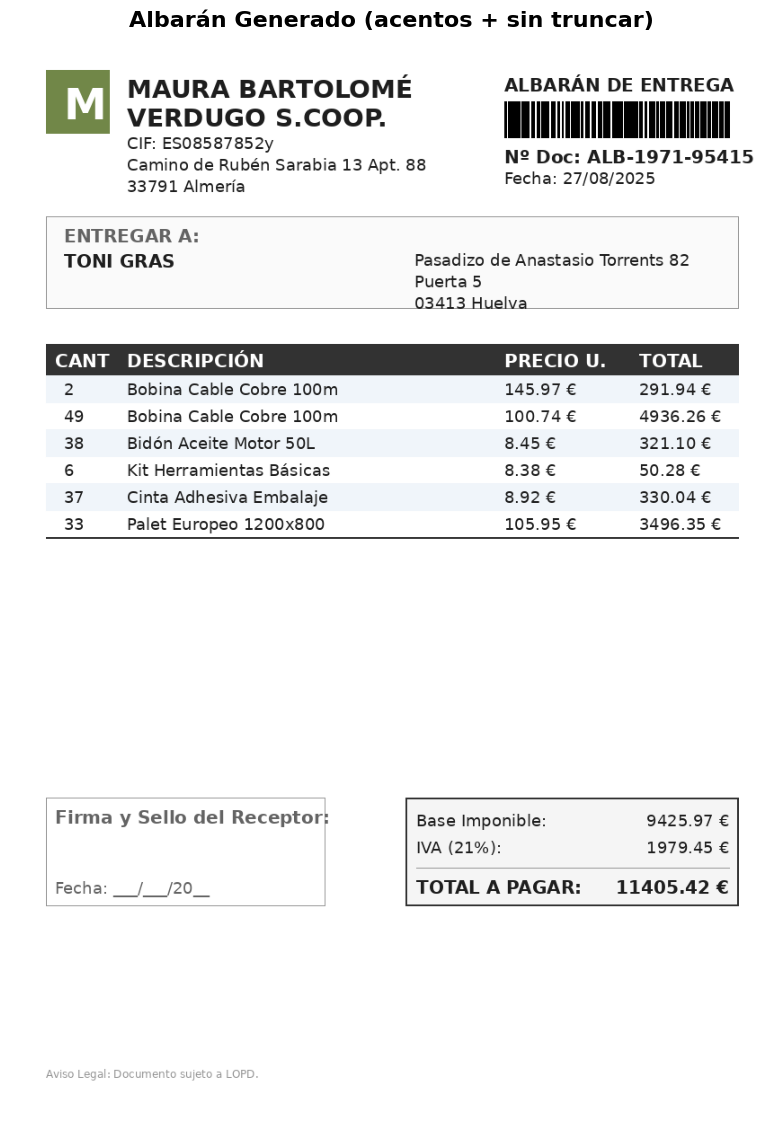

In [ ]:
# ==============================================================================
# DEMOSTRACIÓN VISUAL (render v6: acentos + wrapping + layout que fluye)
# ==============================================================================
import matplotlib.pyplot as plt

generador_pro = GeneradorAlbaranesPro()
datos_pro = generador_pro.generar_datos_json()
img_pro = generador_pro.dibujar_albaran(datos_pro)

plt.figure(figsize=(10, 14))
plt.imshow(img_pro)
plt.title("Albarán Generado (acentos + sin truncar)", fontsize=16, fontweight='bold')
plt.axis('off')
plt.show()

Conectando a Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Iniciando generación de 5000 albaranes corporativos | LIMPIO (sin ruido) | seed=42...


Generando Dataset Sintético:   0%|          | 0/5000 [00:00<?, ?it/s]


Comprimiendo el dataset a un archivo ZIP...
Transfiriendo ZIP a Google Drive -> /content/drive/MyDrive/STUDIES/MASTER/2Q/TFM/01__Dataset/TFM_Dataset_Logistica.zip...
¡Dataset (limpio) generado y guardado permanentemente en el Drive!


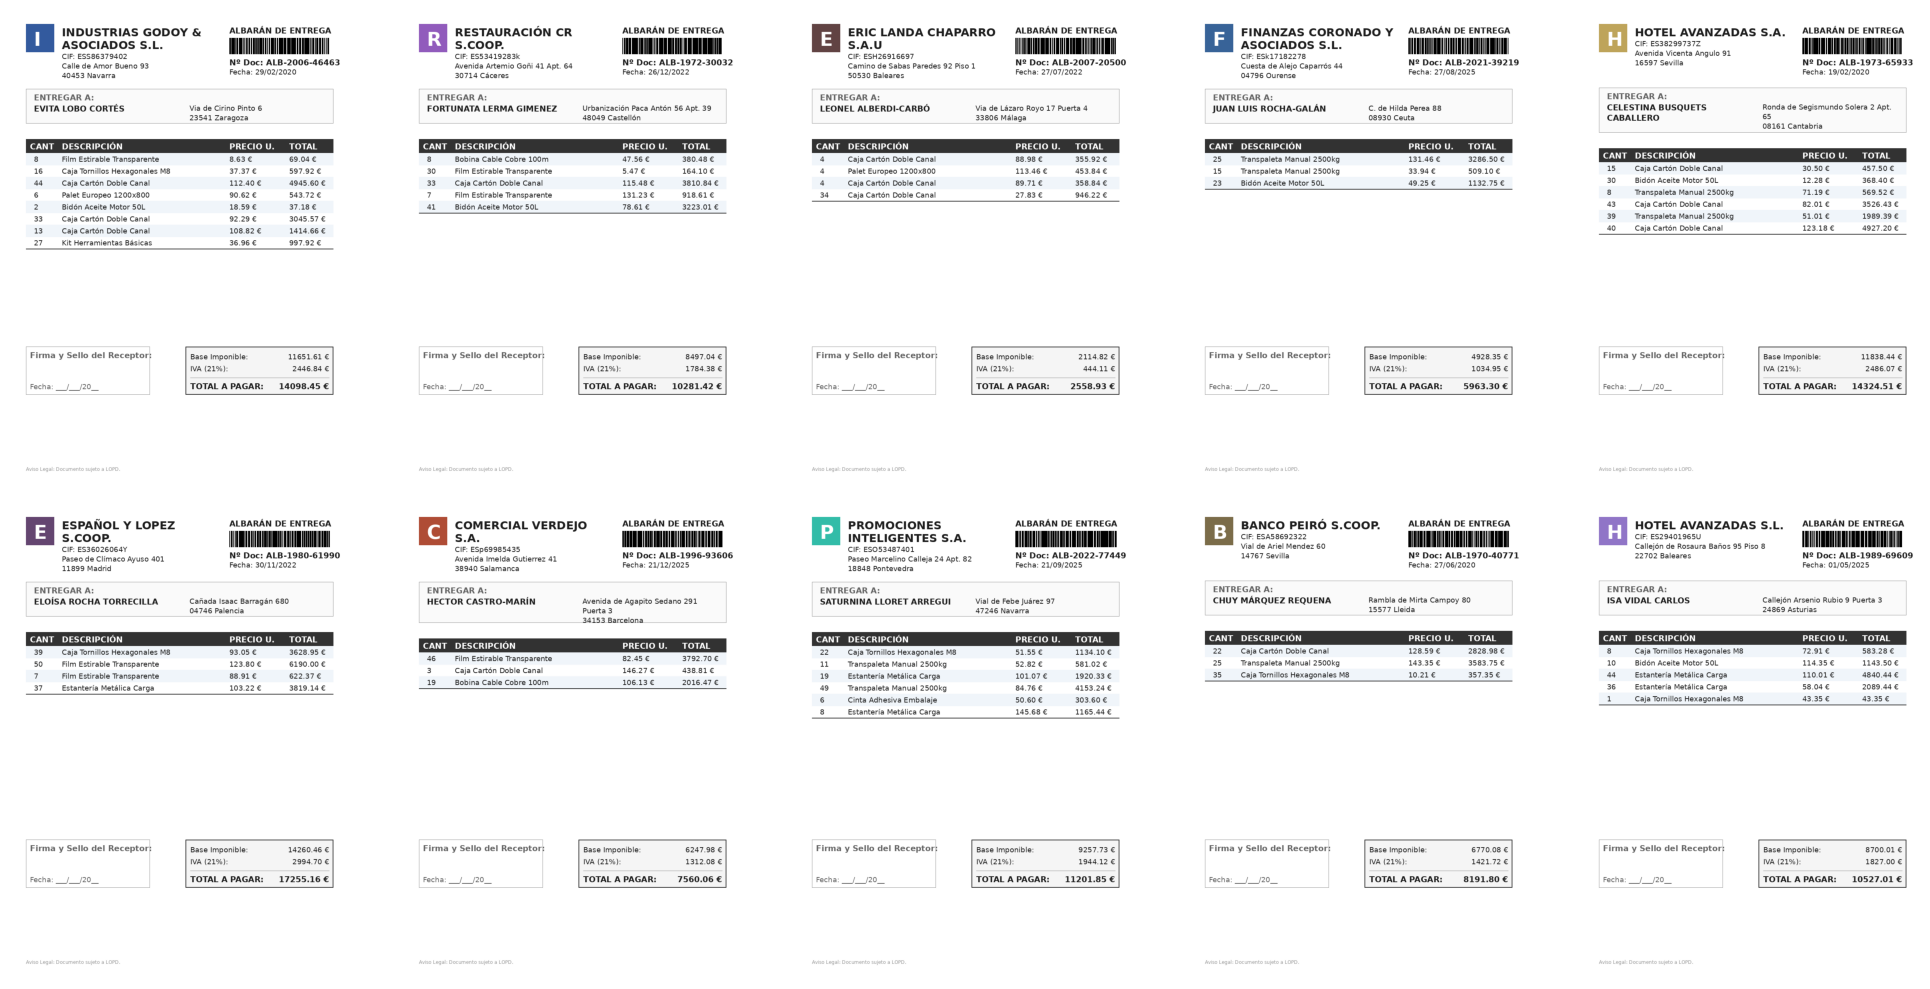

In [ ]:
# ==============================================================================
# CELDA 7: GENERACIÓN MASIVA DEL DATASET SINTÉTICO (TRAIN, LIMPIO + REPRODUCIBLE)
# ==============================================================================
import os
import json
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm
import albumentations as A
from faker import Faker
from google.colab import drive

# ------------------------------------------------------------------------------
# 0. REPRODUCIBILIDAD - Fijamos SEED a 42, sin esto el dataset NO es regenerable de forma identica)
#    Se re-liga el `fake` GLOBAL que usa GeneradorAlbaranesPro (celda 6): al estar
#    Colab en un unico namespace, `generar_datos_json` lo resuelve ya sembrado.
# ------------------------------------------------------------------------------
SEED_TRAIN = 42
random.seed(SEED_TRAIN)
np.random.seed(SEED_TRAIN)
Faker.seed(SEED_TRAIN)
fake = Faker('es_ES')

# ------------------------------------------------------------------------------
# 1. CONEXIÓN A GOOGLE DRIVE
# ------------------------------------------------------------------------------
print("Conectando a Google Drive...")
drive.mount('/content/drive')

# ------------------------------------------------------------------------------
# 2. CONFIGURACIÓN Y PIPELINE
# ------------------------------------------------------------------------------
def get_noise_pipeline(severity=0):
    if severity == 0:
        return None                      # nivel 0 = imagen pristina (igual que el set de robustez)
    return A.Compose([
        A.MotionBlur(p=min(1.0, 0.3 * severity)),
        A.RandomBrightnessContrast(p=min(1.0, 0.4 * severity)),
        A.CoarseDropout(max_holes=5*severity, max_height=20, max_width=20, p=min(1.0, 0.2 * severity)),
        A.SafeRotate(limit=5 * severity, p=0.5)
    ])

NUM_IMAGENES = 5000
NIVEL_RUIDO = 0                          # LIMPIO: base real de la curva de robustez (antes era 3)
LOCAL_DIR = "/content/TFM_Dataset_Logistica"
IMG_DIR = os.path.join(LOCAL_DIR, "images")
METADATA_FILE = os.path.join(LOCAL_DIR, "metadata.jsonl")
DRIVE_DESTINATION = "/content/drive/MyDrive/STUDIES/MASTER/2Q/TFM/01__Dataset/TFM_Dataset_Logistica.zip"

if os.path.exists(LOCAL_DIR): shutil.rmtree(LOCAL_DIR)
os.makedirs(IMG_DIR, exist_ok=True)

nivel_txt = "LIMPIO (sin ruido)" if NIVEL_RUIDO == 0 else f"Ruido Nivel {NIVEL_RUIDO}"
print(f"\nIniciando generación de {NUM_IMAGENES} albaranes corporativos | {nivel_txt} | seed={SEED_TRAIN}...")

# ------------------------------------------------------------------------------
# 3. GENERACIÓN DEL DATASET
# ------------------------------------------------------------------------------
generador_pro = GeneradorAlbaranesPro()          # requiere celda 6 en memoria
pipeline_ruido = get_noise_pipeline(severity=NIVEL_RUIDO)
ejemplos_visuales = []

with open(METADATA_FILE, 'w', encoding='utf-8') as f_meta:
    for i in tqdm(range(NUM_IMAGENES), desc="Generando Dataset Sintético"):
        datos_json = generador_pro.generar_datos_json()
        img_limpia_pil = generador_pro.dibujar_albaran(datos_json)

        if pipeline_ruido is not None:            # respeta el None de nivel 0
            img_final_pil = Image.fromarray(pipeline_ruido(image=np.array(img_limpia_pil))['image'])
        else:
            img_final_pil = img_limpia_pil

        nombre_archivo = f"albaran_pro_{i:05d}.jpg"
        img_final_pil.save(os.path.join(IMG_DIR, nombre_archivo), format="JPEG", quality=85)

        estructura_hf = {
            "file_name": f"images/{nombre_archivo}",
            "ground_truth": json.dumps({"gt_parse": datos_json}, ensure_ascii=False)
        }
        f_meta.write(json.dumps(estructura_hf, ensure_ascii=False) + "\n")

        if i < 10: ejemplos_visuales.append(img_final_pil)

# ------------------------------------------------------------------------------
# 4. EMPAQUETADO Y TRANSFERENCIA
# ------------------------------------------------------------------------------
print("\nComprimiendo el dataset a un archivo ZIP...")
shutil.make_archive(LOCAL_DIR, 'zip', LOCAL_DIR)
print(f"Transfiriendo ZIP a Google Drive -> {DRIVE_DESTINATION}...")
shutil.copy(LOCAL_DIR + ".zip", DRIVE_DESTINATION)
print("¡Dataset (limpio) generado y guardado permanentemente en el Drive!")

fig, axes = plt.subplots(2, 5, figsize=(20, 10))
for idx, img in enumerate(ejemplos_visuales):
    axes.flatten()[idx].imshow(img); axes.flatten()[idx].axis('off')
plt.tight_layout(); plt.show()


### 99.2 - Generación del conjunto de robustez (ejecutar una única vez)

Esta subsección genera el conjunto de datos destinado a las pruebas de robustez, creando 500 documentos para cada nivel de degradación evaluado (`0`, `1`, `2` y `3`).

Para mantener la independencia respecto al conjunto de entrenamiento, se utiliza una semilla específica (`SEED_TEST = 2025`), evitando el solapamiento de muestras y garantizando una evaluación separada.

El proceso se compone de tres etapas:

1. **Generación documental:** creación de los documentos base a partir del generador sintético.
2. **Aplicación de degradaciones:** incorporación progresiva de ruido visual mediante transformaciones de iluminación, desenfoque, pérdida parcial de información y rotaciones.
3. **Etiquetado y almacenamiento:** generación de los archivos `metadata.jsonl`, empaquetado de cada conjunto y copia automática a Google Drive.

**Nota:** Cada nivel de degradación se genera de forma independiente para facilitar su uso en las pruebas de robustez y en la comparación entre modelos.

In [ ]:
# ==============================================================================
# CELDA: FÁBRICA DE ROBUSTEZ (GENERACIÓN MULTI-NIVEL) Y EXPORTACIÓN A DRIVE
# ==============================================================================
import os
import json
import random
import shutil
import numpy as np
import matplotlib.pyplot as plt
from faker import Faker
from PIL import Image, ImageDraw, ImageFont
from tqdm.auto import tqdm
import albumentations as A
from matplotlib import font_manager
from google.colab import drive

# ------------------------------------------------------------------------------
# 1. CONEXIÓN A GOOGLE DRIVE Y CONFIGURACIÓN
# ------------------------------------------------------------------------------
print(" Conectando a Google Drive...")
drive.mount('/content/drive')

NUM_DOCS_POR_RUIDO = 500
NIVELES_RUIDO = [0, 1, 2, 3]
LOCAL_DIR = "/content/TFM_Test_Robustez"
# Ajusta esta ruta a donde quieras guardar el ZIP de test en tu Drive:
DRIVE_DESTINATION = "/content/drive/MyDrive/STUDIES/MASTER/2Q/TFM/01__Dataset/TFM_Test_Robustez.zip"

# Limpieza previa en la RAM de Colab
if os.path.exists(LOCAL_DIR): shutil.rmtree(LOCAL_DIR)
os.makedirs(LOCAL_DIR, exist_ok=True)

# ------------------------------------------------------------------------------
# 2. DEFINICIÓN DEL GENERADOR "CORPORATE"
# ------------------------------------------------------------------------------

# --- REPRODUCIBILIDAD (test): semilla DISTINTA del train (42) para NO solapar docs ---
SEED_TEST = 2025
random.seed(SEED_TEST); np.random.seed(SEED_TEST); Faker.seed(SEED_TEST)

fake = Faker('es_ES')

ARTICULOS_LOGISTICOS = [
    "Palet Europeo 1200x800", "Caja Tornillos Hexagonales M8",
    "Bobina Cable Cobre 100m", "Bidón Aceite Motor 50L",
    "Film Estirable Transparente", "Cinta Adhesiva Embalaje",
    "Estantería Metálica Carga", "Transpaleta Manual 2500kg",
    "Caja Cartón Doble Canal", "Kit Herramientas Básicas"
]

def _find_font(bold=False):
    # Roboto si existe (entorno original); si no, DejaVuSans (acentos garantizados en Colab)
    rel = "Roboto-Bold.ttf" if bold else "Roboto-Regular.ttf"
    if os.path.exists(rel):
        return rel
    fp = font_manager.FontProperties(family='DejaVu Sans', weight=('bold' if bold else 'normal'))
    return font_manager.findfont(fp)

class GeneradorAlbaranesPro:
    def __init__(self):
        reg, bld = _find_font(False), _find_font(True)
        self.f_tiny   = ImageFont.truetype(reg, 12)
        self.f_normal = ImageFont.truetype(reg, 18)
        self.f_bold   = ImageFont.truetype(bld, 20)
        self.f_title  = ImageFont.truetype(bld, 28)   # 32 -> 28 para dar aire al wrapping
        self.f_logo   = ImageFont.truetype(bld, 48)

    def generar_datos_json(self):
        num_lineas = random.randint(3, 8)
        lineas = []
        subtotal = 0.0
        for _ in range(num_lineas):
            cant = random.randint(1, 50)
            precio_uni = round(random.uniform(5.0, 150.0), 2)
            total_linea = round(cant * precio_uni, 2)
            subtotal += total_linea
            lineas.append({"descripcion": random.choice(ARTICULOS_LOGISTICOS),
                           "cantidad": cant, "precio_unitario": precio_uni, "total_linea": total_linea})
        subtotal = round(subtotal, 2)
        iva = round(subtotal * 0.21, 2)
        total_pagar = round(subtotal + iva, 2)
        return {
            "tipo_documento": "ALBARÁN DE ENTREGA",
            "numero_albaran": f"ALB-{fake.year()}-{random.randint(10000, 99999)}",
            "fecha": fake.date_this_decade().strftime("%d/%m/%Y"),
            "proveedor": {"nombre": fake.company(), "direccion": fake.street_address(),
                          "ciudad": f"{fake.postcode()} {fake.city()}", "cif": fake.vat_id()},
            "cliente": {"nombre": fake.name(), "direccion": fake.street_address(),
                        "ciudad": f"{fake.postcode()} {fake.city()}"},
            "lineas": lineas, "subtotal": subtotal, "iva_21": iva, "total": total_pagar
        }

    @staticmethod
    def _wrap(draw, text, font, max_w):
        words = str(text).split()
        lines, cur = [], ""
        for w in words:
            test = (cur + " " + w).strip()
            if not cur or draw.textlength(test, font=font) <= max_w:
                cur = test
            else:
                lines.append(cur); cur = w
        if cur: lines.append(cur)
        return lines or [""]

    def _draw_wrapped(self, draw, xy, text, font, max_w, fill, lh=None):
        x, y = xy
        lh = lh or (font.size + 6)
        for ln in self._wrap(draw, text, font, max_w):
            draw.text((x, y), ln, font=font, fill=fill); y += lh
        return y

    def _dibujar_codigo_barras(self, draw, x_start, y_start, width, height):
        x = x_start
        while x < x_start + width:
            w = random.randint(1, 4)
            draw.rectangle([x, y_start, x+w, y_start+height], fill=(0,0,0)); x += w + random.randint(1, 3)

    def dibujar_albaran(self, datos):
        img = Image.new('RGB', (850, 1200), color=(255, 255, 255))
        draw = ImageDraw.Draw(img); tc = (30, 30, 30)

        cl = (random.randint(50,200), random.randint(50,200), random.randint(50,200))
        draw.rectangle([40, 40, 110, 110], fill=cl)
        draw.text((60, 50), datos['proveedor']['nombre'][0], font=self.f_logo, fill=(255,255,255))

        PROV_W = 400
        y = 45
        y = self._draw_wrapped(draw, (130, y), datos['proveedor']['nombre'].upper(), self.f_title, PROV_W, tc, lh=32)
        y += 2
        y = self._draw_wrapped(draw, (130, y), f"CIF: {datos['proveedor']['cif']}", self.f_normal, PROV_W, tc)
        y = self._draw_wrapped(draw, (130, y), datos['proveedor']['direccion'], self.f_normal, PROV_W, tc)
        y = self._draw_wrapped(draw, (130, y), datos['proveedor']['ciudad'], self.f_normal, PROV_W, tc)
        prov_bottom = y

        draw.text((550, 45), datos['tipo_documento'], font=self.f_bold, fill=tc)
        self._dibujar_codigo_barras(draw, 550, 75, 250, 40)
        draw.text((550, 125), f"Nº Doc: {datos['numero_albaran']}", font=self.f_bold, fill=tc)
        draw.text((550, 150), f"Fecha: {datos['fecha']}", font=self.f_normal, fill=tc)
        meta_bottom = 180

        cli_top = max(prov_bottom, meta_bottom) + 20
        nom_lines = self._wrap(draw, datos['cliente']['nombre'].upper(), self.f_bold, 360)
        dir_lines = self._wrap(draw, datos['cliente']['direccion'], self.f_normal, 330)
        cli_lines = self._wrap(draw, datos['cliente']['ciudad'], self.f_normal, 330)
        alto_izq = 30 + len(nom_lines)*26
        alto_der = len(dir_lines)*24 + len(cli_lines)*24
        cli_h = max(alto_izq, alto_der) + 30
        draw.rectangle([40, cli_top, 810, cli_top+cli_h], outline=(150,150,150), width=1, fill=(250,250,250))
        draw.text((60, cli_top+10), "ENTREGAR A:", font=self.f_bold, fill=(100,100,100))
        self._draw_wrapped(draw, (60, cli_top+38), datos['cliente']['nombre'].upper(), self.f_bold, 360, tc, lh=26)
        yd = self._draw_wrapped(draw, (450, cli_top+38), datos['cliente']['direccion'], self.f_normal, 330, tc)
        self._draw_wrapped(draw, (450, yd), datos['cliente']['ciudad'], self.f_normal, 330, tc)

        y_actual = cli_top + cli_h + 40
        draw.rectangle([40, y_actual, 810, y_actual+35], fill=(50,50,50))
        draw.text((50, y_actual+7), "CANT", font=self.f_bold, fill=(255,255,255))
        draw.text((130, y_actual+7), "DESCRIPCIÓN", font=self.f_bold, fill=(255,255,255))
        draw.text((550, y_actual+7), "PRECIO U.", font=self.f_bold, fill=(255,255,255))
        draw.text((700, y_actual+7), "TOTAL", font=self.f_bold, fill=(255,255,255))
        y_actual += 35
        for idx, ln in enumerate(datos['lineas']):
            if idx % 2 == 0: draw.rectangle([40, y_actual, 810, y_actual+30], fill=(240,245,250))
            draw.text((60, y_actual+5), str(ln['cantidad']), font=self.f_normal, fill=tc)
            draw.text((130, y_actual+5), ln['descripcion'][:30], font=self.f_normal, fill=tc)
            draw.text((550, y_actual+5), f"{ln['precio_unitario']:.2f} €", font=self.f_normal, fill=tc)
            draw.text((700, y_actual+5), f"{ln['total_linea']:.2f} €", font=self.f_normal, fill=tc)
            y_actual += 30
        draw.line([(40,y_actual),(810,y_actual)], fill=(50,50,50), width=2)

        y_tot = max(y_actual+40, 850)
        draw.rectangle([40, y_tot, 350, y_tot+120], outline=(150,150,150), width=1)
        draw.text((50, y_tot+10), "Firma y Sello del Receptor:", font=self.f_bold, fill=(100,100,100))
        draw.text((50, y_tot+90), "Fecha: ___/___/20__", font=self.f_normal, fill=(100,100,100))
        draw.rectangle([440, y_tot, 810, y_tot+120], fill=(245,245,245), outline=(50,50,50), width=2)
        def _rt(txt, yy, font):
            w = draw.textlength(txt, font=font)
            draw.text((800 - w, yy), txt, font=font, fill=tc)
        draw.text((452, y_tot+15), "Base Imponible:", font=self.f_normal, fill=tc)
        _rt(f"{datos['subtotal']:.2f} €", y_tot+15, self.f_normal)
        draw.text((452, y_tot+45), "IVA (21%):", font=self.f_normal, fill=tc)
        _rt(f"{datos['iva_21']:.2f} €", y_tot+45, self.f_normal)
        draw.line([(452,y_tot+78),(800,y_tot+78)], fill=(150,150,150), width=1)
        draw.text((452, y_tot+88), "TOTAL A PAGAR:", font=self.f_bold, fill=tc)
        _rt(f"{datos['total']:.2f} €", y_tot+88, self.f_bold)
        draw.text((40, 1150), "Aviso Legal: Documento sujeto a LOPD.", font=self.f_tiny, fill=(150,150,150))
        return img

# 3. PIPELINE DE RUIDO Y GENERACIÓN MULTINIVEL
# ------------------------------------------------------------------------------
def get_noise_pipeline(severity=0):
    if severity == 0:
        return None # Cero ruido, imagen prístina
    return A.Compose([
        A.MotionBlur(p=min(1.0, 0.3 * severity)),
        A.RandomBrightnessContrast(p=min(1.0, 0.4 * severity)),
        A.CoarseDropout(max_holes=5*severity, max_height=20, max_width=20, p=min(1.0, 0.2 * severity)),
        A.SafeRotate(limit=5 * severity, p=0.5)
    ])

print(f"\nIniciando generación de {NUM_DOCS_POR_RUIDO} albaranes por cada nivel de ruido (0 a 3)...")
generador_pro = GeneradorAlbaranesPro()

for ruido in NIVELES_RUIDO:
    # Creamos subcarpeta para este nivel (ej: /content/TFM_Test_Robustez/Ruido_1)
    carpeta_ruido = os.path.join(LOCAL_DIR, f"Ruido_{ruido}")
    os.makedirs(carpeta_ruido, exist_ok=True)

    # Creamos subcarpeta 'images' dentro, necesario para HuggingFace
    carpeta_imagenes = os.path.join(carpeta_ruido, "images")
    os.makedirs(carpeta_imagenes, exist_ok=True)

    ruta_metadata = os.path.join(carpeta_ruido, "metadata.jsonl")
    pipeline_ruido = get_noise_pipeline(severity=ruido)

    with open(ruta_metadata, "w", encoding="utf-8") as archivo_metadata:
        for i in tqdm(range(NUM_DOCS_POR_RUIDO), desc=f"Generando Nivel {ruido}"):
            # Generar datos limpios
            datos_json = generador_pro.generar_datos_json()
            img_limpia_pil = generador_pro.dibujar_albaran(datos_json)

            # Aplicar ruido si corresponde
            if pipeline_ruido is not None:
                img_np = np.array(img_limpia_pil)
                img_degradada_np = pipeline_ruido(image=img_np)['image']
                img_final_pil = Image.fromarray(img_degradada_np)
            else:
                img_final_pil = img_limpia_pil

            # Guardar imagen (en la subcarpeta images)
            nombre_archivo = f"test_r{ruido}_{i:04d}.jpg"
            ruta_imagen = os.path.join(carpeta_imagenes, nombre_archivo)
            img_final_pil.save(ruta_imagen, format="JPEG", quality=85)

            # Escribir metadata
            linea_metadata = {
                "file_name": f"images/{nombre_archivo}",
                "ground_truth": json.dumps({"gt_parse": datos_json}, ensure_ascii=False)
            }
            archivo_metadata.write(json.dumps(linea_metadata, ensure_ascii=False) + "\n")

print("\n Comprimiendo el laboratorio de robustez a un archivo ZIP...")
shutil.make_archive(LOCAL_DIR, 'zip', LOCAL_DIR)

print(f" Transfiriendo ZIP a Google Drive -> {DRIVE_DESTINATION}...")
shutil.copy(LOCAL_DIR + ".zip", DRIVE_DESTINATION)
print(" ¡Test Sets generados y guardados permanentemente!")

 Conectando a Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Iniciando generación de 500 albaranes por cada nivel de ruido (0 a 3)...


Generando Nivel 0:   0%|          | 0/500 [00:00<?, ?it/s]

Generando Nivel 1:   0%|          | 0/500 [00:00<?, ?it/s]

Generando Nivel 2:   0%|          | 0/500 [00:00<?, ?it/s]

Generando Nivel 3:   0%|          | 0/500 [00:00<?, ?it/s]


 Comprimiendo el laboratorio de robustez a un archivo ZIP...
 Transfiriendo ZIP a Google Drive -> /content/drive/MyDrive/STUDIES/MASTER/2Q/TFM/01__Dataset/TFM_Test_Robustez.zip...
 ¡Test Sets generados y guardados permanentemente!


### 99.3 - Preparación del modelo y entrenamiento

Esta subsección prepara la arquitectura DONUT para su ajuste fino utilizando el conjunto de datos sintético generado previamente.

El proceso se desarrolla en tres etapas:

1. **Construcción del vocabulario:** extracción de las etiquetas presentes en los archivos de referencia para ampliar el tokenizador con los campos específicos del dominio logístico.
2. **Preparación de los datos:** partición del conjunto de datos en entrenamiento, validación y prueba (80/10/10), seguida del preprocesamiento de imágenes y anotaciones.
3. **Configuración del entrenamiento:** carga del modelo preentrenado, adaptación de los *embeddings* al nuevo vocabulario e inicialización del entrenamiento con mecanismos de optimización de memoria, como precisión mixta, *gradient checkpointing* y acumulación de gradientes.

**Nota:** Estas técnicas permiten realizar el ajuste fino del modelo en entornos con recursos de GPU limitados, manteniendo la estabilidad del proceso de entrenamiento.

In [ ]:
# ==============================================================================
# CELDA 9: PREPARACIÓN DEL DATASET Y MOTOR DE ENTRENAMIENTO ANTI-OOM (FASE 3)
# ==============================================================================
import json
import torch
import gc
from datasets import load_dataset
from transformers import DonutProcessor, VisionEncoderDecoderModel, Seq2SeqTrainingArguments, Seq2SeqTrainer
from torch.utils.data import Dataset

# ------------------------------------------------------------------------------
# 0. LIMPIEZA EXTREMA DE MEMORIA Y SETUP DE GPU
# ------------------------------------------------------------------------------
print("Limpiando la basura de la memoria RAM y VRAM...")
gc.collect()
torch.cuda.empty_cache()
device = "cuda" if torch.cuda.is_available() else "cpu"
if device == "cuda":
    print(f"GPU detectada. VRAM actual usada: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")

# ------------------------------------------------------------------------------
# 1. CARGA DEL DATASET Y DESCUBRIMIENTO DE TOKENS
# ------------------------------------------------------------------------------
print("\n1. Cargando el modelo base (Procesador) y el dataset sintético...")
processor = DonutProcessor.from_pretrained("naver-clova-ix/donut-base")

dataset_path = "/content/TFM_Dataset_Logistica"
raw_dataset = load_dataset("imagefolder", data_dir=dataset_path, split="train")

# json2token() se define ahora en la celda de Utilidades (seccion 01).

nuevos_tokens = set()
for sample in raw_dataset:
    gt = json.loads(sample['ground_truth'])['gt_parse']
    def extraer_claves(diccionario):
        for k, v in diccionario.items():
            nuevos_tokens.add(f"<s_{k}>")
            nuevos_tokens.add(f"</s_{k}>")
            if isinstance(v, dict): extraer_claves(v)
            elif isinstance(v, list) and len(v) > 0 and isinstance(v[0], dict):
                for item in v: extraer_claves(item)
    extraer_claves(gt)

nuevos_tokens.add("<sep/>")
processor.tokenizer.add_special_tokens({"additional_special_tokens": sorted(list(nuevos_tokens))})
print(f"Se han añadido {len(nuevos_tokens)} tokens estructurales al vocabulario de Donut.")

# ------------------------------------------------------------------------------
# 2. DIVISION TRAIN/VAL/TEST Y PYTORCH DATASET
# ------------------------------------------------------------------------------
print("\n2. Dividiendo el dataset (80% Train, 10% Val, 10% Test Ciego)...")
split_1 = raw_dataset.train_test_split(test_size=0.2, seed=42)
split_2 = split_1["test"].train_test_split(test_size=0.5, seed=42)

dataset_train, dataset_val, dataset_test = split_1["train"], split_2["train"], split_2["test"]
print(f"Distribución final: Train ({len(dataset_train)}), Validacion ({len(dataset_val)}), Test ({len(dataset_test)})")

class AlbaranesDataset(Dataset):
    def __init__(self, dataset_hf, processor, max_length=512):
        self.dataset = dataset_hf
        self.processor = processor
        self.max_length = max_length

    def __len__(self): return len(self.dataset)

    def __getitem__(self, idx):
        item = self.dataset[idx]
        imagen = item["image"].convert("RGB")
        pixel_values = self.processor(
            imagen, size={"height": 1280, "width": 960}, return_tensors="pt"
        ).pixel_values.squeeze()

        gt_dict = json.loads(item["ground_truth"])["gt_parse"]
        secuencia_tokens = json2token(gt_dict) + self.processor.tokenizer.eos_token
        input_ids = self.processor.tokenizer(
            secuencia_tokens, add_special_tokens=False, max_length=self.max_length,
            padding="max_length", truncation=True, return_tensors="pt"
        )["input_ids"].squeeze(0)

        labels = input_ids.clone()
        labels[labels == self.processor.tokenizer.pad_token_id] = -100
        return {"pixel_values": pixel_values, "labels": labels}

train_dataset = AlbaranesDataset(dataset_train, processor)
val_dataset = AlbaranesDataset(dataset_val, processor)

# ------------------------------------------------------------------------------
# 3. ARQUITECTURA DEL MODELO Y CONFIGURACIÓN
# ------------------------------------------------------------------------------
print("\n3. Cargando arquitectura neuronal Donut Base en precisión estándar (FP32 master)...")
# CORRECCIÓN: Quitamos torch_dtype=torch.float16. Dejamos que PyTorch lo cargue en 32 bits.
model = VisionEncoderDecoderModel.from_pretrained("naver-clova-ix/donut-base")

model.decoder.resize_token_embeddings(len(processor.tokenizer))
model.config.pad_token_id = processor.tokenizer.pad_token_id
model.config.decoder_start_token_id = processor.tokenizer.convert_tokens_to_ids("<s_cord-v2>")
model.to(device)
print(f"Arquitectura Donut adaptada y cargada en: {device}")

def donut_collate_fn(batch):
    pixel_values = torch.stack([item["pixel_values"] for item in batch])
    labels = torch.stack([item["labels"] for item in batch])
    return {"pixel_values": pixel_values, "labels": labels}

print("\n4. Configurando hiperparámetros del Trainer (Estrategia OOM Extrema)...")
training_args = Seq2SeqTrainingArguments(
    output_dir="/content/drive/MyDrive/STUDIES/MASTER/2Q/TFM/02__Modelos/TFM_DONUT_logistica_Checkpoints",
    per_device_train_batch_size=2,   # Se aumenta de 1 -> 2 tras observar el uso de VRAM
    per_device_eval_batch_size=2,    # Se aumenta de 1 -> 2 tras observar el uso de VRAM
    gradient_accumulation_steps=4,   # Se disminuye de 8 a 4, tras usar batch_size = 2
    gradient_checkpointing=True,
    optim="adamw_torch",
    learning_rate=4e-5,
    weight_decay=0.01,
    num_train_epochs=5,
    logging_steps=10,
    eval_strategy="steps",
    eval_steps=100,
    save_strategy="steps",
    save_steps=100,
    save_total_limit=2,
    fp16=True, # AMP: El Trainer lo bajará dinámicamente a 16 bits sin corromper la matemática
    predict_with_generate=True,
    report_to="none",
    load_best_model_at_end=True,
    metric_for_best_model="loss",
)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=donut_collate_fn,
)

print("Todo listo. Entorno, Dataset y Modelo preparados para entrenar sin crashear.")

Limpiando la basura de la memoria RAM y VRAM...
GPU detectada. VRAM actual usada: 0.00 GB

1. Cargando el modelo base (Procesador) y el dataset sintético...


Resolving data files:   0%|          | 0/5001 [00:00<?, ?it/s]

Se han añadido 35 tokens estructurales al vocabulario de Donut.

2. Dividiendo el dataset (80% Train, 10% Val, 10% Test Ciego)...
Distribución final: Train (4000), Validacion (500), Test (500)

3. Cargando arquitectura neuronal Donut Base en precisión estándar (FP32 master)...


Loading weights:   0%|          | 0/484 [00:00<?, ?it/s]

[transformers] The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


Arquitectura Donut adaptada y cargada en: cuda

4. Configurando hiperparámetros del Trainer (Estrategia OOM Extrema)...
Todo listo. Entorno, Dataset y Modelo preparados para entrenar sin crashear.


### 99.4 - Entrenamiento y almacenamiento del modelo

Esta subsección ejecuta el proceso de ajuste fino de DONUT y gestiona el almacenamiento seguro de los resultados.

- **Reanudación automática:** si existen puntos de control previamente guardados, el entrenamiento continúa desde el último estado disponible.
- **Protección ante errores:** se supervisa la ejecución para evitar la sobrescritura de modelos válidos en caso de interrupciones o fallos durante el entrenamiento.
- **Persistencia final:** una vez completado el proceso, se almacenan el modelo ajustado y el tokenizador actualizado en Google Drive para su posterior uso en inferencia y evaluación.

**Nota:** Este mecanismo permite recuperar entrenamientos interrumpidos y preservar los resultados obtenidos en entornos de ejecución temporales como Google Colab.

In [ ]:
# ==============================================================================
# CELDA 10: EJECUCIÓN DEL FINE-TUNING (CON RECUPERACIÓN ANTE CAÍDAS)
# ==============================================================================
import time
import datetime
import torch
import os

print("="*80)
print("INICIANDO / RETOMANDO FINE-TUNING DE DONUT")
print("="*80)

start_time = time.time()
entrenamiento_exitoso = False

# 1. Sistema de detección de Checkpoints en Drive
dir_checkpoints = "/content/drive/MyDrive/STUDIES/MASTER/2Q/TFM/02__Modelos/TFM_DONUT_logistica_Checkpoints"
hay_checkpoints = os.path.exists(dir_checkpoints) and len(os.listdir(dir_checkpoints)) > 0

if hay_checkpoints:
    print("¡Checkpoints previos detectados en Drive!")
    print("Retomando el entrenamiento exactamente donde se cortó...")
else:
    print("No se encontraron checkpoints. Iniciando entrenamiento desde cero...")

# 2. ¡Arrancamos el motor!
try:
    # Si encuentra archivos retoma el entrenamiento
    with medir_recursos('train', n_items=None, extra={'modelo': 'DONUT'}):
        trainer.train(resume_from_checkpoint=hay_checkpoints)

    entrenamiento_exitoso = True

    end_time = time.time()
    tiempo_total = str(datetime.timedelta(seconds=int(end_time - start_time)))
    pico_vram_train = torch.cuda.max_memory_allocated() / (1024**3)

    print("\n" + "="*80)
    print(f"¡ENTRENAMIENTO COMPLETADO CON ÉXITO EN {tiempo_total}!")
    print(f"Pico máximo de VRAM consumida en Entrenamiento: {pico_vram_train:.2f} GB")
    print("="*80)

except Exception as e:
    print("\n Error crítico durante el entrenamiento:")
    print(e)
    print("\n El entrenamiento se detuvo.")

# 3. Guardado blindado (¡SOLO SI EL ENTRENAMIENTO TERMINÓ BIEN!)
if entrenamiento_exitoso and 'trainer' in locals():
    print(f"\n Guardando el modelo final y el tokenizador en Drive...")

    RUTAS_MODELO_FINAL = "/content/drive/MyDrive/STUDIES/MASTER/2Q/TFM/02__Modelos/TFM_DONUT_logistica_ModeloFinal"

    trainer.save_model(RUTAS_MODELO_FINAL)
    processor.save_pretrained(RUTAS_MODELO_FINAL)

    print(f"¡Modelo empaquetado y guardado en el Drive: {RUTAS_MODELO_FINAL}!")
else:
    print("\nGUARDADO CANCELADO: No se guardará el modelo final para evitar corromper archivos.")

INICIANDO / RETOMANDO FINE-TUNING DE DONUT
No se encontraron checkpoints. Iniciando entrenamiento desde cero...


[transformers] `use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


Step,Training Loss,Validation Loss
100,3.931627,0.903153
200,0.301744,0.044278
300,0.117416,0.019322
400,0.081639,0.014462
500,0.044688,0.008113
600,0.035154,0.006307
700,0.029127,0.005930
800,0.024751,0.005163
900,0.030211,0.005433
1000,0.016768,0.004162


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['decoder.lm_head.weight'].


[BENCH] train: 14879.50s | CPU~94.0% | RAM 2098.0MB | VRAM 7476.4MB | disco R/W 2614.16/0.0MB

¡ENTRENAMIENTO COMPLETADO CON ÉXITO EN 4:07:59!
Pico máximo de VRAM consumida en Entrenamiento: 7.30 GB

 Guardando el modelo final y el tokenizador en Drive...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

¡Modelo empaquetado y guardado en el Drive: /content/drive/MyDrive/STUDIES/MASTER/2Q/TFM/02__Modelos/TFM_DONUT_logistica_ModeloFinal!
